In [1]:
import re
import gc

from collections import Counter, defaultdict
from functools import lru_cache
from pathlib import Path

import numpy as np
import pandas as pd
import torch

import warnings
warnings.filterwarnings(action="ignore")

from pymorphy3 import MorphAnalyzer
from stop_words import get_stop_words

from IPython.display import display

import matplotlib as mpl
mpl.rcParams["font.style"] = "oblique"
mpl.rcParams["axes.grid"] = True

import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")

from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import normalize, Normalizer
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import pairwise_distances, pairwise_distances_argmin

from umap import UMAP
from hdbscan import HDBSCAN

from sklearn.metrics import (
    adjusted_rand_score,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)
from sklearn.metrics.cluster import pair_confusion_matrix
from scipy.stats import spearmanr
from scipy.cluster.hierarchy import linkage, fcluster

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)


In [2]:
df = pd.read_csv("./data.csv")
df.head()

,row_id,text,original_label,story_id,message_type,hierarchy_l1,hierarchy_l2,hierarchy_l3,hierarchy_l4,hierarchy_l5,hierarchy,hF1_path,hF1_ancestors,story_size,review_status,review_reason
0,1,"❗️Визит президента Сербии в силе, он летит в М...",9may_politics,vucic_victory_day_moscow_visit,fact,politics,international_relations,russia_serbia,victory_day_80,NaN,politics/international_relations/russia_serbia...,root/politics/international_relations/russia_s...,root|root/politics|root/politics/international...,15,review,check_boundary_with_adjacent_story
1,2,"Самолет президента Сербии Вучича, направлявший...",9may_politics,vucic_victory_day_moscow_visit,fact,politics,international_relations,russia_serbia,victory_day_80,NaN,politics/international_relations/russia_serbia...,root/politics/international_relations/russia_s...,root|root/politics|root/politics/international...,15,review,check_boundary_with_adjacent_story
2,3,Власти Литвы запретили перелет в воздушном про...,9may_politics,vucic_victory_day_moscow_visit,fact,politics,international_relations,russia_serbia,victory_day_80,NaN,politics/international_relations/russia_serbia...,root/politics/international_relations/russia_s...,root|root/politics|root/politics/international...,15,review,check_boundary_with_adjacent_story
3,4,"Вучич, прервавший поездку в США из-за недомога...",9may_politics,vucic_victory_day_moscow_visit,fact,politics,international_relations,russia_serbia,victory_day_80,NaN,politics/international_relations/russia_serbia...,root/politics/international_relations/russia_s...,root|root/politics|root/politics/international...,15,review,check_boundary_with_adjacent_story;exact_dupli...
4,5,"Вучич, прервавший поездку в США из-за недомога...",vuchich_ill,vucic_health_incident,fact,politics,europe,serbia,leadership_health,NaN,politics/europe/serbia/leadership_health,root/politics/europe/serbia/leadership_health/...,root|root/politics|root/politics/europe|root/p...,4,review,check_boundary_with_adjacent_story;exact_dupli...


In [3]:
df.shape

(863, 16)

In [4]:
MORPH = MorphAnalyzer()
RU_STOPWORDS = set(get_stop_words("russian"))

In [5]:
#del model_embeddings2

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

In [6]:
model_statistics = make_pipeline(
    TfidfVectorizer(
        lowercase=True,
        max_features=50000,
        ngram_range=(1, 2)
    ),
    TruncatedSVD(
        n_components=300,
        random_state=42
    ),
    Normalizer(copy=False)
)

In [7]:
# todo: run both
#model_embeddings1 = SentenceTransformer(
#    "jinaai/jina-embeddings-v3", trust_remote_code=True, device="cuda"
#)
#model_embeddings2 = SentenceTransformer(
#    "jinaai/jina-embeddings-v5-text-small", trust_remote_code=True, device="cuda"
#)

# gpu issue (FP 16 mode)
#model_embeddings1.half()
#model_embeddings2.half()

In [8]:
def make_noise_singletons(y_pred, noise_label=-1):
    y_pred = np.asarray(y_pred).copy()
    noise_mask = y_pred == noise_label

    if not np.any(noise_mask):
        return y_pred

    non_noise = y_pred[~noise_mask]
    next_label = int(np.max(non_noise)) + 1 if non_noise.size else 0

    for offset, idx in enumerate(np.where(noise_mask)[0]):
        y_pred[idx] = next_label + offset

    return y_pred


def fbeta_score_from_precision_recall(precision, recall, beta=1.0):
    beta2 = beta ** 2
    denominator = beta2 * precision + recall

    if denominator == 0:
        return 0

    return (1 + beta2) * precision * recall / denominator


def pairwise_metrics(y_true, y_pred):
    tn, fp, fn, tp = pair_confusion_matrix(y_true, y_pred).ravel()

    precision = tp / (tp + fp) if tp + fp > 0 else 0
    recall = tp / (tp + fn) if tp + fn > 0 else 0

    f1 = fbeta_score_from_precision_recall(precision, recall, beta=1.0)
    f05 = fbeta_score_from_precision_recall(precision, recall, beta=0.5)

    return precision, recall, f1, f05


In [9]:
def compute_true_paths(df, col="hF1_ancestors", sep="|"):
    return [
        [node for node in str(value).split(sep) if node]
        for value in df[col]
    ]


def strip_root(path, root="root"):
    return [node for node in path if node != root]


def gold_hierarchy_nodes(true_paths, root="root", min_size=2):
    n = len(true_paths)
    groups = defaultdict(list)

    for i, path in enumerate(true_paths):
        for node in strip_root(path, root):
            groups[node].append(i)

    return [
        frozenset(indices)
        for indices in groups.values()
        if min_size <= len(set(indices)) < n
    ]


def weighted_best_overlap_f1(source_nodes, target_nodes):
    if not source_nodes or not target_nodes:
        return np.nan

    total_weight = 0
    weighted_sum = 0.0

    for source in source_nodes:
        source_size = len(source)
        best_f1 = 0.0

        for target in target_nodes:
            intersection = len(source & target)
            if intersection == 0:
                continue

            best_f1 = max(
                best_f1,
                2 * intersection / (len(source) + len(target))
            )

        weighted_sum += source_size * best_f1
        total_weight += source_size

    return weighted_sum / total_weight if total_weight else np.nan


def condensed_tree_to_pandas(condensed_tree):
    if condensed_tree is None:
        return None

    if hasattr(condensed_tree, "to_pandas"):
        return condensed_tree.to_pandas()

    if isinstance(condensed_tree, pd.DataFrame):
        return condensed_tree.copy()

    raise TypeError("condensed_tree must be an HDBSCAN CondensedTree or a pandas DataFrame")


def build_condensed_tree_info(condensed_tree, n_samples):
    tree_df = condensed_tree_to_pandas(condensed_tree)

    if tree_df is None or tree_df.empty:
        return None

    children = defaultdict(list)
    parent_of = {}
    child_size = {}
    lambda_val = {}

    for row in tree_df.itertuples(index=False):
        parent = int(row.parent)
        child = int(row.child)
        children[parent].append(child)
        parent_of[child] = parent
        child_size[child] = int(row.child_size)
        lambda_val[child] = float(row.lambda_val)

    parent_nodes = set(children.keys())
    child_nodes = set(parent_of.keys())
    roots = list(parent_nodes - child_nodes)

    if roots:
        root = roots[0]
    else:
        # Fallback for unexpected formats: choose the parent with the largest covered subtree.
        root = max(parent_nodes, key=lambda node: len(children[node]))

    all_nodes = parent_nodes | child_nodes | set(range(n_samples))

    @lru_cache(maxsize=None)
    def collect_leaves(node):
        if node < n_samples:
            return frozenset([node])

        leaves = frozenset()
        for child in children.get(node, []):
            leaves = leaves | collect_leaves(child)

        return leaves

    leaf_sets = {
        node: collect_leaves(node)
        for node in all_nodes
        if node >= n_samples or node in parent_of
    }

    sample_paths = {}
    for sample_idx in range(n_samples):
        path = []
        node = sample_idx
        seen = set()

        while node in parent_of and node not in seen:
            seen.add(node)
            parent = parent_of[node]
            if parent >= n_samples:
                path.append(parent)
            node = parent

        # Root-to-leaf cluster path. Sample node itself is intentionally excluded.
        sample_paths[sample_idx] = list(reversed(path))

    return {
        "tree_df": tree_df,
        "children": children,
        "parent_of": parent_of,
        "child_size": child_size,
        "lambda_val": lambda_val,
        "root": root,
        "leaf_sets": leaf_sets,
        "sample_paths": sample_paths,
    }


def condensed_tree_to_hierarchy_nodes(condensed_tree, n_samples, min_size=2, include_root=False):
    info = build_condensed_tree_info(condensed_tree, n_samples)

    if info is None:
        return []

    root = info["root"]
    nodes = []
    seen = set()

    for node, leaves in info["leaf_sets"].items():
        if node < n_samples:
            continue

        size = len(leaves)
        if size < min_size:
            continue
        if node == root and not include_root:
            continue
        if size >= n_samples and not include_root:
            continue
        if leaves in seen:
            continue

        seen.add(leaves)
        nodes.append(leaves)

    return nodes


def hierarchical_cluster_fscore(condensed_tree, true_paths, root="root", min_size=2):
    n = len(true_paths)
    gold_nodes = gold_hierarchy_nodes(true_paths, root=root, min_size=min_size)
    pred_nodes = condensed_tree_to_hierarchy_nodes(condensed_tree, n, min_size=min_size)

    h_precision = weighted_best_overlap_f1(pred_nodes, gold_nodes)
    h_recall = weighted_best_overlap_f1(gold_nodes, pred_nodes)

    if np.isfinite(h_precision) and np.isfinite(h_recall) and h_precision + h_recall > 0:
        h_f1 = 2 * h_precision * h_recall / (h_precision + h_recall)
    else:
        h_f1 = np.nan

    return h_precision, h_recall, h_f1


def common_prefix_len(path_a, path_b, root="root"):
    length = 0

    for node_a, node_b in zip(path_a, path_b):
        if node_a != node_b:
            break
        if node_a != root:
            length += 1

    return length


@lru_cache(maxsize=8)
def _gold_hierarchy_pairwise_arrays_cached(paths, root="root"):
    n = len(paths)
    n_pairs = n * (n - 1) // 2

    lca_similarity = np.empty(n_pairs, dtype=float)
    tree_distance = np.empty(n_pairs, dtype=float)
    path_depths = [len(strip_root(path, root=root)) for path in paths]

    k = 0
    for i in range(n - 1):
        for j in range(i + 1, n):
            lca_depth = common_prefix_len(paths[i], paths[j], root=root)

            lca_similarity[k] = lca_depth
            tree_distance[k] = path_depths[i] + path_depths[j] - 2 * lca_depth
            k += 1

    return lca_similarity, tree_distance


def gold_hierarchy_pairwise_arrays(true_paths, root="root"):
    return _gold_hierarchy_pairwise_arrays_cached(
        tuple(tuple(path) for path in true_paths),
        root=root,
    )


def condensed_tree_pairwise_arrays(condensed_tree, n_samples):
    info = build_condensed_tree_info(condensed_tree, n_samples)

    if info is None:
        return None, None

    sample_paths = info["sample_paths"]
    root = info["root"]
    n_pairs = n_samples * (n_samples - 1) // 2

    pred_lca_similarity = np.empty(n_pairs, dtype=float)
    pred_tree_distance = np.empty(n_pairs, dtype=float)

    def path_depth(path):
        return sum(node != root for node in path)

    def lca_depth(path_a, path_b):
        depth = 0
        for node_a, node_b in zip(path_a, path_b):
            if node_a != node_b:
                break
            if node_a != root:
                depth += 1
        return depth

    path_depths = [path_depth(sample_paths[i]) for i in range(n_samples)]

    k = 0
    for i in range(n_samples - 1):
        for j in range(i + 1, n_samples):
            lca = lca_depth(sample_paths[i], sample_paths[j])
            pred_lca_similarity[k] = lca
            pred_tree_distance[k] = path_depths[i] + path_depths[j] - 2 * lca
            k += 1

    return pred_lca_similarity, pred_tree_distance


def safe_spearman(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)

    if mask.sum() < 2:
        return np.nan

    x = x[mask]
    y = y[mask]

    if len(np.unique(x)) < 2 or len(np.unique(y)) < 2:
        return np.nan

    return spearmanr(x, y).correlation


def hierarchical_tree_metrics(condensed_tree, true_paths, root="root"):
    if condensed_tree is None:
        return {
            "lca_similarity_spearman": np.nan,
            "tree_distance_spearman": np.nan,
        }

    n = len(true_paths)
    gold_lca, gold_distance = gold_hierarchy_pairwise_arrays(true_paths, root=root)
    pred_lca, pred_distance = condensed_tree_pairwise_arrays(condensed_tree, n)

    if pred_lca is None or pred_distance is None:
        return {
            "lca_similarity_spearman": np.nan,
            "tree_distance_spearman": np.nan,
        }

    return {
        "lca_similarity_spearman": safe_spearman(gold_lca, pred_lca),
        "tree_distance_spearman": safe_spearman(gold_distance, pred_distance),
    }


def condensed_dendrogram_purity(condensed_tree, y_true):
    if condensed_tree is None:
        return np.nan

    y_true = np.asarray(y_true)
    n = len(y_true)
    info = build_condensed_tree_info(condensed_tree, n)

    if info is None:
        return np.nan

    root = info["root"]
    sample_paths = info["sample_paths"]
    leaf_sets = info["leaf_sets"]

    node_counts = {}
    for node, leaves in leaf_sets.items():
        if node >= n and leaves:
            node_counts[node] = Counter(y_true[list(leaves)])

    def lca_node(path_a, path_b):
        lca = root
        for node_a, node_b in zip(path_a, path_b):
            if node_a != node_b:
                break
            lca = node_a
        return lca

    purity_sum = 0.0
    pair_count = 0

    for i in range(n - 1):
        label = y_true[i]
        for j in range(i + 1, n):
            if y_true[j] != label:
                continue

            node = lca_node(sample_paths[i], sample_paths[j])
            leaves = leaf_sets.get(node, frozenset(range(n)))
            size = len(leaves)

            if size == 0:
                continue

            counts = node_counts.get(node, Counter(y_true[list(leaves)]))
            purity_sum += counts[label] / size
            pair_count += 1

    return purity_sum / pair_count if pair_count else np.nan


# --- HDBSCAN + agglomerative topic hierarchy helpers ---

def assign_noise_to_nearest_topic(X_topic, y_pred, noise_label=-1):
    """Assign HDBSCAN noise documents to the nearest non-noise topic centroid.

    HDBSCAN labels are kept for flat metrics; this reassignment is used only for
    the topic hierarchy so that every document gets a path in the tree.
    """
    y_topic = np.asarray(y_pred).copy()
    topic_ids = np.array(sorted(label for label in set(y_topic) if label != noise_label))

    if len(topic_ids) == 0:
        return y_topic

    centroids = np.vstack([
        X_topic[y_topic == topic_id].mean(axis=0)
        for topic_id in topic_ids
    ])
    centroids = normalize(centroids)

    noise_mask = y_topic == noise_label
    if np.any(noise_mask):
        nearest = pairwise_distances_argmin(
            X_topic[noise_mask],
            centroids,
            metric="cosine",
        )
        y_topic[noise_mask] = topic_ids[nearest]

    return y_topic


def build_topic_representations(
    X_topic,
    y_topic,
    representation="medoid",
    distance_metric="cosine",
):
    topic_ids = sorted(set(y_topic))

    if len(topic_ids) == 0:
        return np.empty((0, X_topic.shape[1])), [], {}, {}

    representatives = []
    for topic_id in topic_ids:
        topic_vectors = X_topic[y_topic == topic_id]

        if representation == "centroid":
            representative = topic_vectors.mean(axis=0)
        elif representation == "medoid":
            if len(topic_vectors) == 1:
                representative = topic_vectors[0]
            else:
                distances = pairwise_distances(topic_vectors, metric=distance_metric)
                medoid_idx = int(np.argmin(distances.mean(axis=1)))
                representative = topic_vectors[medoid_idx]
        else:
            raise ValueError("representation must be 'centroid' or 'medoid'")

        representatives.append(representative)

    representatives = normalize(np.vstack(representatives))

    topic_id_to_idx = {topic_id: idx for idx, topic_id in enumerate(topic_ids)}
    idx_to_topic_id = {idx: topic_id for topic_id, idx in topic_id_to_idx.items()}

    return representatives, topic_ids, topic_id_to_idx, idx_to_topic_id


def linkage_to_topic_paths(Z, topic_ids, include_leaf=True):
    """Return root-to-leaf paths for each HDBSCAN topic from scipy linkage."""
    n_topics = len(topic_ids)

    if n_topics == 0:
        return {}

    if n_topics == 1 or Z is None:
        leaf_path = [0] if include_leaf else []
        return {topic_ids[0]: leaf_path}

    parent_of = {}
    for merge_idx, row in enumerate(Z):
        parent = n_topics + merge_idx
        parent_of[int(row[0])] = parent
        parent_of[int(row[1])] = parent

    topic_paths = {}
    for topic_idx, topic_id in enumerate(topic_ids):
        path = []
        node = topic_idx

        while node in parent_of:
            parent = parent_of[node]
            path.append(parent)
            node = parent

        path = list(reversed(path))
        if include_leaf:
            path.append(topic_idx)

        topic_paths[topic_id] = path

    return topic_paths


def document_paths_from_topic_paths(y_topic, topic_paths):
    return [topic_paths[label] for label in y_topic]


def agglomerative_hierarchy_nodes_from_linkage(
    Z,
    topic_ids,
    y_topic,
    min_size=2,
    include_root=False,
    include_leaf_topics=True,
):
    """Convert topic-level agglomerative tree into document-set hierarchy nodes."""
    n_topics = len(topic_ids)
    n_docs = len(y_topic)

    if n_topics == 0:
        return []

    topic_to_docs = {
        topic_id: frozenset(np.where(y_topic == topic_id)[0])
        for topic_id in topic_ids
    }
    node_docs = {
        topic_idx: topic_to_docs[topic_id]
        for topic_idx, topic_id in enumerate(topic_ids)
    }

    nodes = []
    seen = set()

    if include_leaf_topics:
        for topic_idx in range(n_topics):
            docs = node_docs[topic_idx]
            if min_size <= len(docs) < n_docs and docs not in seen:
                seen.add(docs)
                nodes.append(docs)

    if Z is None:
        return nodes

    root = n_topics + len(Z) - 1
    for merge_idx, row in enumerate(Z):
        parent = n_topics + merge_idx
        docs = node_docs[int(row[0])] | node_docs[int(row[1])]
        node_docs[parent] = docs

        if parent == root and not include_root:
            continue
        if len(docs) >= n_docs and not include_root:
            continue
        if len(docs) < min_size:
            continue
        if docs in seen:
            continue

        seen.add(docs)
        nodes.append(docs)

    return nodes


def hierarchy_pairwise_arrays_from_paths(pred_paths):
    n = len(pred_paths)
    n_pairs = n * (n - 1) // 2

    pred_lca_similarity = np.empty(n_pairs, dtype=float)
    pred_tree_distance = np.empty(n_pairs, dtype=float)
    path_depths = [len(path) for path in pred_paths]

    k = 0
    for i in range(n - 1):
        for j in range(i + 1, n):
            lca = 0
            for node_a, node_b in zip(pred_paths[i], pred_paths[j]):
                if node_a != node_b:
                    break
                lca += 1

            pred_lca_similarity[k] = lca
            pred_tree_distance[k] = path_depths[i] + path_depths[j] - 2 * lca
            k += 1

    return pred_lca_similarity, pred_tree_distance


def hierarchical_cluster_fscore_from_nodes(pred_nodes, true_paths, root="root", min_size=2):
    gold_nodes = gold_hierarchy_nodes(true_paths, root=root, min_size=min_size)

    h_precision = weighted_best_overlap_f1(pred_nodes, gold_nodes)
    h_recall = weighted_best_overlap_f1(gold_nodes, pred_nodes)

    if np.isfinite(h_precision) and np.isfinite(h_recall) and h_precision + h_recall > 0:
        h_f1 = 2 * h_precision * h_recall / (h_precision + h_recall)
    else:
        h_f1 = np.nan

    return h_precision, h_recall, h_f1


def hierarchical_tree_metrics_from_paths(pred_paths, true_paths, root="root"):
    if pred_paths is None:
        return {
            "lca_similarity_spearman": np.nan,
            "tree_distance_spearman": np.nan,
        }

    gold_lca, gold_distance = gold_hierarchy_pairwise_arrays(true_paths, root=root)
    pred_lca, pred_distance = hierarchy_pairwise_arrays_from_paths(pred_paths)

    return {
        "lca_similarity_spearman": safe_spearman(gold_lca, pred_lca),
        "tree_distance_spearman": safe_spearman(gold_distance, pred_distance),
    }


def dendrogram_purity_from_paths(pred_paths, y_true):
    """Dendrogram purity for a predicted hierarchy represented as document paths."""
    if pred_paths is None:
        return np.nan

    y_true = np.asarray(y_true)
    n = len(y_true)

    node_to_docs = defaultdict(list)
    for doc_idx, path in enumerate(pred_paths):
        for node in path:
            node_to_docs[node].append(doc_idx)

    node_counts = {
        node: Counter(y_true[doc_indices])
        for node, doc_indices in node_to_docs.items()
    }
    node_sizes = {
        node: len(doc_indices)
        for node, doc_indices in node_to_docs.items()
    }

    def lca_node(path_a, path_b):
        lca = None
        for node_a, node_b in zip(path_a, path_b):
            if node_a != node_b:
                break
            lca = node_a
        return lca

    purity_sum = 0.0
    pair_count = 0

    for i in range(n - 1):
        label = y_true[i]
        for j in range(i + 1, n):
            if y_true[j] != label:
                continue

            node = lca_node(pred_paths[i], pred_paths[j])
            if node is None:
                size = n
                count = Counter(y_true)[label]
            else:
                size = node_sizes[node]
                count = node_counts[node][label]

            if size == 0:
                continue

            purity_sum += count / size
            pair_count += 1

    return purity_sum / pair_count if pair_count else np.nan



MISSING_LEVEL = "<missing_level>"


def gold_level_labels(true_paths, depth, root="root", missing_label=MISSING_LEVEL):
    """Gold partition labels at a fixed hierarchy depth, excluding the root.

    Paths shorter than the requested depth are marked as missing instead of
    repeating their leaf label; this prevents artificial duplicate metrics for
    depths beyond the real annotation depth.
    """
    labels = []

    for path in true_paths:
        path_without_root = strip_root(path, root=root)

        if len(path_without_root) >= depth:
            labels.append(path_without_root[depth - 1])
        else:
            labels.append(missing_label)

    return np.asarray(labels, dtype=object)


def topic_cut_labels_from_linkage(Z, topic_ids, y_topic, n_clusters):
    """Cut topic-level agglomerative tree into n_clusters and map labels to documents."""
    topic_ids = list(topic_ids)
    n_topics = len(topic_ids)

    if n_topics == 0:
        return np.full(len(y_topic), -1)

    if n_topics == 1:
        return np.zeros(len(y_topic), dtype=int)

    n_clusters = int(max(1, min(n_clusters, n_topics)))

    if n_clusters == n_topics:
        topic_cluster_labels = np.arange(n_topics)
    else:
        topic_cluster_labels = fcluster(Z, t=n_clusters, criterion="maxclust")

    topic_to_cluster = {
        topic_id: topic_cluster_labels[topic_idx]
        for topic_idx, topic_id in enumerate(topic_ids)
    }

    return np.asarray([topic_to_cluster[topic_id] for topic_id in y_topic])


def levelwise_hierarchy_f1_metrics(hierarchy_output, true_paths, root="root"):
    """Evaluate hierarchy as a sequence of level cuts.

    For each real gold depth d, cut the predicted topic dendrogram into the same
    number of clusters as gold has at depth d, then compute pairwise F1 between
    the two partitions. Documents without annotation at depth d are excluded for
    that depth instead of repeating their leaf labels.
    """
    if hierarchy_output is None or hierarchy_output.get("topic_labels") is None:
        return {
            "level_macro_f1": np.nan,
            "level_weighted_f1": np.nan,
        }

    y_topic = hierarchy_output["topic_labels"]
    topic_ids = hierarchy_output["topic_ids"]
    Z = hierarchy_output["linkage"]
    max_depth = max(len(strip_root(path, root=root)) for path in true_paths)

    result = {}
    f1_values = []
    weights = []
    depth_f1_values = {}

    for depth in range(1, max_depth + 1):
        gold_labels = gold_level_labels(true_paths, depth=depth, root=root)
        valid_mask = gold_labels != MISSING_LEVEL

        if valid_mask.sum() < 2:
            result[f"level_f1_depth_{depth}"] = np.nan
            continue

        gold_labels_valid = gold_labels[valid_mask]
        n_gold_clusters = len(np.unique(gold_labels_valid))

        if n_gold_clusters < 2:
            result[f"level_f1_depth_{depth}"] = np.nan
            continue

        pred_labels = topic_cut_labels_from_linkage(
            Z=Z,
            topic_ids=topic_ids,
            y_topic=y_topic,
            n_clusters=n_gold_clusters,
        )[valid_mask]

        _, _, level_f1, _ = pairwise_metrics(gold_labels_valid, pred_labels)

        cluster_sizes = Counter(gold_labels_valid)
        positive_pairs = sum(size * (size - 1) // 2 for size in cluster_sizes.values())
        n_valid_docs = len(gold_labels_valid)
        total_pairs = n_valid_docs * (n_valid_docs - 1) // 2
        # Keep every valid level represented even if it has tiny positive-pair mass.
        weight = positive_pairs / total_pairs if total_pairs else 0

        result[f"level_f1_depth_{depth}"] = level_f1
        f1_values.append(level_f1)
        weights.append(weight)
        depth_f1_values[depth] = level_f1

    upper_f1_values = [value for depth, value in depth_f1_values.items() if depth <= 2]
    lower_f1_values = [value for depth, value in depth_f1_values.items() if depth >= 3]

    if f1_values:
        result["level_macro_f1"] = float(np.mean(f1_values))
        result["level_upper_macro_f1"] = float(np.mean(upper_f1_values)) if upper_f1_values else np.nan
        result["level_lower_macro_f1"] = float(np.mean(lower_f1_values)) if lower_f1_values else np.nan
        if np.sum(weights) > 0:
            result["level_weighted_f1"] = float(np.average(f1_values, weights=weights))
        else:
            result["level_weighted_f1"] = float(np.mean(f1_values))
    else:
        result["level_macro_f1"] = np.nan
        result["level_upper_macro_f1"] = np.nan
        result["level_lower_macro_f1"] = np.nan
        result["level_weighted_f1"] = np.nan

    return result


def build_hdbscan_agglomerative_hierarchy(
    X_topic,
    y_pred,
    assign_noise=True,
    topic_representation="medoid",
    linkage_method="average",
    linkage_metric="cosine",
    include_leaf_topics=True,
):
    """Build BERTopic-style hierarchy: HDBSCAN topics -> representatives -> agglomerative tree."""
    if assign_noise:
        y_topic = assign_noise_to_nearest_topic(X_topic, y_pred)
    else:
        y_topic = np.asarray(y_pred).copy()

    valid_mask = y_topic != -1
    if not np.all(valid_mask):
        # If noise is not assigned, keep hierarchy over non-noise topics impossible for all docs.
        return {
            "topic_labels": y_topic,
            "topic_ids": [],
            "linkage": None,
            "topic_paths": {},
            "pred_paths": None,
            "pred_nodes": [],
            "n_topics": 0,
        }

    topic_representations, topic_ids, _, _ = build_topic_representations(
        X_topic,
        y_topic,
        representation=topic_representation,
        distance_metric=linkage_metric,
    )

    if len(topic_ids) < 2:
        Z = None
    else:
        Z = linkage(
            topic_representations,
            method=linkage_method,
            metric=linkage_metric,
        )

    topic_paths = linkage_to_topic_paths(
        Z,
        topic_ids,
        include_leaf=include_leaf_topics,
    )
    pred_paths = document_paths_from_topic_paths(y_topic, topic_paths)
    pred_nodes = agglomerative_hierarchy_nodes_from_linkage(
        Z,
        topic_ids,
        y_topic,
        include_leaf_topics=include_leaf_topics,
    )

    return {
        "topic_labels": y_topic,
        "topic_ids": topic_ids,
        "linkage": Z,
        "topic_paths": topic_paths,
        "pred_paths": pred_paths,
        "pred_nodes": pred_nodes,
        "n_topics": len(topic_ids),
        "topic_representation": topic_representation,
    }


In [10]:
def tfidf_preprocessing(text):
    text = re.sub(r"[^а-яё\s]", " ", text.lower())
    result = []

    for token in text.split():
        if len(token) < 2: continue
        lemma = MORPH.parse(token)[0].normal_form
        if lemma in RU_STOPWORDS: continue

        result.append(lemma)

    return " ".join(result)

In [11]:
def clustering_metrics(X, y_true, y_pred, true_paths=None, hierarchy_output=None):
    y_pred_external = make_noise_singletons(y_pred)
    precision, recall, f1, f05 = pairwise_metrics(y_true, y_pred_external)
    ari = adjusted_rand_score(y_true, y_pred_external)

    if true_paths is not None and hierarchy_output is not None:
        level_metrics = levelwise_hierarchy_f1_metrics(
            hierarchy_output=hierarchy_output,
            true_paths=true_paths,
        )
        tree_metrics = hierarchical_tree_metrics_from_paths(
            pred_paths=hierarchy_output["pred_paths"],
            true_paths=true_paths,
        )
        purity = dendrogram_purity_from_paths(hierarchy_output["pred_paths"], y_true)
    else:
        level_metrics = {
            "level_macro_f1": np.nan,
            "level_weighted_f1": np.nan,
        }
        tree_metrics = {
            "lca_similarity_spearman": np.nan,
            "tree_distance_spearman": np.nan,
        }
        purity = np.nan

    mask = y_pred != -1
    internal = {
        "silhouette": np.nan,
        "calinski_harabasz": np.nan,
        "davies_bouldin": np.nan,
    }

    # Noise handling intentionally stays as before: internal metrics are computed on clustered points only.
    if len(set(y_pred[mask])) >= 2:
        internal["silhouette"] = silhouette_score(X[mask], y_pred[mask])
        internal["calinski_harabasz"] = calinski_harabasz_score(X[mask], y_pred[mask])
        internal["davies_bouldin"] = davies_bouldin_score(X[mask], y_pred[mask])

    return {
        "precision": precision,
        "recall": recall,
        "f1-score": f1,
        "f0.5-score": f05,
        **level_metrics,
        "lca_similarity_spearman": tree_metrics["lca_similarity_spearman"],
        "tree_distance_spearman": tree_metrics["tree_distance_spearman"],
        "dendrogram_purity": purity,
        "ari": ari,
        **internal
    }


In [12]:
def twonn_dimension(X, metric="euclidean", eps=1e-12):
    X = np.asarray(X)

    if len(X) < 3:
        return np.nan

    nn = NearestNeighbors(n_neighbors=3, metric=metric)
    nn.fit(X)
    distances, _ = nn.kneighbors(X)

    r1 = distances[:, 1]
    r2 = distances[:, 2]
    mask = np.isfinite(r1) & np.isfinite(r2) & (r1 > eps) & (r2 > eps)

    if mask.sum() < 3:
        return np.nan

    log_mu = np.log(r2[mask] / r1[mask])
    mean_log_mu = np.mean(log_mu)

    return 1 / mean_log_mu if mean_log_mu > eps else np.nan


def reduce_embeddings(
    X,
    pca_dim=100,
    umap_dim=15,
    return_twonn=False,
    use_pca=False,
    umap_seed=42,
):
    twonn_raw = twonn_dimension(X)

    X_norm = normalize(X)
    pca_dim = min(pca_dim, X_norm.shape[1], X_norm.shape[0] - 1)
    if use_pca:
        X_pca = PCA(
            n_components=pca_dim,
            random_state=42,
        ).fit_transform(X_norm)
    else:
        X_pca = X_norm.copy()
        
    twonn_pca = twonn_dimension(X_pca)
    X_umap = UMAP(
        n_components=umap_dim,
        metric="cosine",
        random_state=umap_seed,
    ).fit_transform(X_pca)
    twonn_umap = twonn_dimension(X_umap)

    if return_twonn:
        return X_umap, {
            "twonn_raw": twonn_raw,
            "twonn_pca": twonn_pca,
            "twonn_umap": twonn_umap,
        }

    return X_umap


In [13]:
def run_clusterers(
    X,
    X_topic,
    min_cluster_size=5,
    hierarchy_topic_representation="medoid",
    hierarchy_linkage_method="average",
    hierarchy_linkage_metric="cosine",
):
    hdbscan = HDBSCAN(
        min_cluster_size=min_cluster_size,
        metric="euclidean",
        gen_min_span_tree=True,
    ).fit(X)

    hierarchy_output = build_hdbscan_agglomerative_hierarchy(
        X_topic=X_topic,
        y_pred=hdbscan.labels_,
        assign_noise=True,
        topic_representation=hierarchy_topic_representation,
        linkage_method=hierarchy_linkage_method,
        linkage_metric=hierarchy_linkage_metric,
        include_leaf_topics=True,
    )

    return {
        "hdbscan": {
            "labels": hdbscan.labels_,
            "condensed_tree": hdbscan.condensed_tree_,
            "hierarchy_output": hierarchy_output,
            "hierarchy_method": f"agglomerative_{hierarchy_topic_representation}_{hierarchy_linkage_method}_{hierarchy_linkage_metric}",
            "dbcv": hdbscan.relative_validity_,
        },
    }


In [14]:
#for tf-idf
df["text_processed"] = df["text"].apply(tfidf_preprocessing)

In [15]:
texts = df["text"].astype(str).tolist()
preproc_texts = df["text_processed"].tolist()
y_true = df["original_label"].astype(str).to_numpy()
true_paths = compute_true_paths(df)

embeddings_dict = {}
embeddings_dict["tfidf_svd"] = model_statistics.fit_transform(preproc_texts)
#embeddings_dict["jina_embeddings_v3"] = model_embeddings1.encode(
#    texts,
#    task="separation",
#    batch_size=8,
#    show_progress_bar=True,
#    normalize_embeddings=True
#)
#embeddings_dict["jina_embeddings_v5-text-small"] = model_embeddings2.encode(
#    texts,
#    task="text-matching",
#    batch_size=8,
#    show_progress_bar=True,
#    normalize_embeddings=True
#)


In [16]:
embeddings_dict["jina_embeddings_v5_text_small_matching"] = np.load("./embeddings/embeddings_v5_text_small.npy")
embeddings_dict["jina_embeddings_v3"] = np.load("./embeddings/embeddings_v3_separation.npy")

In [17]:

def make_space_id(emb_name, reduction_method, reduction_dim=None, umap_seed=None):
    if reduction_dim is None:
        return f"{emb_name}__{reduction_method}"

    if reduction_method == "umap" and umap_seed is not None:
        return f"{emb_name}__{reduction_method}_{reduction_dim}__seed_{umap_seed}"

    return f"{emb_name}__{reduction_method}_{reduction_dim}"


def build_embedding_spaces(
    embeddings_dict,
    umap_dims=(5, 10, 15, 30, 50),
    umap_seeds=(42,),
    include_raw=True,
    pca_dim=100,
):
    spaces = {}

    for emb_name, X_raw in embeddings_dict.items():
        print(f"Preparing spaces for embeddings: {emb_name}")
        use_pca = False if "jina_embeddings" in emb_name else True

        if include_raw:
            X_raw_norm = normalize(X_raw)
            space_id = make_space_id(emb_name, "raw", X_raw_norm.shape[1])
            spaces[space_id] = {
                "space_id": space_id,
                "embeddings": emb_name,
                "reduction": "raw",
                "reduction_dim": X_raw_norm.shape[1],
                "umap_seed": "raw",
                "X": X_raw_norm,
                "twonn": {
                    "twonn_raw": twonn_dimension(X_raw),
                    "twonn_pca": np.nan,
                    "twonn_umap": np.nan,
                    "twonn_space": twonn_dimension(X_raw_norm),
                },
            }

        for umap_dim in umap_dims:
            for umap_seed in umap_seeds:
                print(f"  UMAP dim: {umap_dim}, seed: {umap_seed}")
                X_reduced, twonn_metrics = reduce_embeddings(
                    X_raw,
                    pca_dim=pca_dim,
                    umap_dim=umap_dim,
                    return_twonn=True,
                    use_pca=use_pca,
                    umap_seed=umap_seed,
                )
                twonn_metrics = dict(twonn_metrics)
                twonn_metrics["twonn_space"] = twonn_metrics["twonn_umap"]

                space_id = make_space_id(emb_name, "umap", umap_dim, umap_seed=umap_seed)
                spaces[space_id] = {
                    "space_id": space_id,
                    "embeddings": emb_name,
                    "reduction": "umap",
                    "reduction_dim": umap_dim,
                    "umap_seed": umap_seed,
                    "X": X_reduced,
                    "twonn": twonn_metrics,
                }

    return spaces


def full_pipeline(
    embeddings_dict,
    min_cluster_sizes=[5, 10, 15, 20],
    umap_dims=(5, 10, 15, 30, 50),
    umap_seeds=(42,),
    include_raw=True,
):
    spaces = build_embedding_spaces(
        embeddings_dict,
        umap_dims=umap_dims,
        umap_seeds=umap_seeds,
        include_raw=include_raw,
    )

    results_total = {}
    for idx, min_cluster_size in enumerate(min_cluster_sizes):
        results_clustering = []
        print(f"{idx+1} out of {len(min_cluster_sizes)}")

        for space_id, space_data in spaces.items():
            X_space = space_data["X"]
            # HDBSCAN is fitted in X_space; topic hierarchy is built from topic representatives
            # in the original embedding space to preserve semantic distances.
            X_topic = normalize(embeddings_dict[space_data["embeddings"]])
            twonn_metrics = space_data["twonn"]
        
            clusterers_output = run_clusterers(
                X_space,
                X_topic=X_topic,
                min_cluster_size=min_cluster_size,
            )
        
            for algo_name, clusterer_output in clusterers_output.items():
                y_pred = clusterer_output["labels"]
                hierarchy_output = clusterer_output["hierarchy_output"]
                metrics = clustering_metrics(
                    X=X_space,
                    y_true=y_true,
                    y_pred=y_pred,
                    true_paths=true_paths,
                    hierarchy_output=hierarchy_output,
                )
        
                results_clustering.append({
                    "space_id": space_id,
                    "embeddings": space_data["embeddings"],
                    "reduction": space_data["reduction"],
                    "reduction_dim": space_data["reduction_dim"],
                    "umap_seed": space_data["umap_seed"],
                    "algorithm": algo_name,
                    "hierarchy_method": clusterer_output["hierarchy_method"],
                    **metrics,
                    "dbcv": clusterer_output["dbcv"],
                    **twonn_metrics,
                    "n_pred_clusters": len(set(y_pred)) - int(-1 in y_pred),
                    "n_noise": int(np.sum(y_pred == -1)),
                    "n_hierarchy_topics": hierarchy_output["n_topics"],
                })
        
        results_df = pd.DataFrame(results_clustering)
        level_metric_cols = [
            col for col in results_df.columns
            if col.startswith("level_f1_depth_")
        ]
        level_metric_cols = sorted(
            level_metric_cols,
            key=lambda col: int(col.rsplit("_", 1)[-1]),
        )
        ordered_cols = [
            "algorithm",
            "hierarchy_method",
            "space_id",
            "embeddings",
            "reduction",
            "reduction_dim",
            "umap_seed",
            "precision",
            "recall",
            "f1-score",
            "f0.5-score",
            "level_macro_f1",
            "level_upper_macro_f1",
            "level_lower_macro_f1",
            "level_weighted_f1",
            *level_metric_cols,
            "lca_similarity_spearman",
            "tree_distance_spearman",
            "dendrogram_purity",
            "ari",
            "silhouette",
            "calinski_harabasz",
            "davies_bouldin",
            "dbcv",
            "twonn_raw",
            "twonn_pca",
            "twonn_umap",
            "twonn_space",
            "n_pred_clusters",
            "n_noise",
            "n_hierarchy_topics",
        ]
        results_df = results_df[[col for col in ordered_cols if col in results_df.columns]]
        results_total[f"res_{min_cluster_size}"] = results_df
    
    return results_total


In [18]:
results_dfs = full_pipeline(
    embeddings_dict,
    min_cluster_sizes=np.arange(2, 30, 1),
    umap_dims=[5, 10, 15, 30, 50],
    umap_seeds=[0, 1, 2, 3, 4, 42],
    include_raw=True,
)


Preparing spaces for embeddings: tfidf_svd
  UMAP dim: 5, seed: 0
  UMAP dim: 5, seed: 1
  UMAP dim: 5, seed: 2
  UMAP dim: 5, seed: 3
  UMAP dim: 5, seed: 4
  UMAP dim: 5, seed: 42
  UMAP dim: 10, seed: 0
  UMAP dim: 10, seed: 1
  UMAP dim: 10, seed: 2
  UMAP dim: 10, seed: 3
  UMAP dim: 10, seed: 4
  UMAP dim: 10, seed: 42
  UMAP dim: 15, seed: 0
  UMAP dim: 15, seed: 1
  UMAP dim: 15, seed: 2
  UMAP dim: 15, seed: 3
  UMAP dim: 15, seed: 4
  UMAP dim: 15, seed: 42
  UMAP dim: 30, seed: 0
  UMAP dim: 30, seed: 1
  UMAP dim: 30, seed: 2
  UMAP dim: 30, seed: 3
  UMAP dim: 30, seed: 4
  UMAP dim: 30, seed: 42
  UMAP dim: 50, seed: 0
  UMAP dim: 50, seed: 1
  UMAP dim: 50, seed: 2
  UMAP dim: 50, seed: 3
  UMAP dim: 50, seed: 4
  UMAP dim: 50, seed: 42
Preparing spaces for embeddings: jina_embeddings_v5_text_small_matching
  UMAP dim: 5, seed: 0
  UMAP dim: 5, seed: 1
  UMAP dim: 5, seed: 2
  UMAP dim: 5, seed: 3
  UMAP dim: 5, seed: 4
  UMAP dim: 5, seed: 42
  UMAP dim: 10, seed: 0
  U

In [19]:
for title, df in list(results_dfs.items())[:5]:
    print(title)
    display(df)

res_2


,algorithm,hierarchy_method,space_id,embeddings,reduction,reduction_dim,umap_seed,precision,recall,f1-score,...,calinski_harabasz,davies_bouldin,dbcv,twonn_raw,twonn_pca,twonn_umap,twonn_space,n_pred_clusters,n_noise,n_hierarchy_topics
0,hdbscan,agglomerative_centroid_average_cosine,tfidf_svd__raw_300,tfidf_svd,raw,300,raw,0.789959,0.215270,0.338340,...,4.423986,1.850667,0.072705,5.884047,NaN,NaN,5.884047,89,305,89
1,hdbscan,agglomerative_centroid_average_cosine,tfidf_svd__umap_5__seed_0,tfidf_svd,umap,5,0,0.871893,0.388190,0.537203,...,4002.717390,0.447759,0.353376,5.884047,4.828226,2.596647,2.596647,102,83,102
2,hdbscan,agglomerative_centroid_average_cosine,tfidf_svd__umap_5__seed_1,tfidf_svd,umap,5,1,0.897484,0.387486,0.541277,...,5247.274491,0.437785,0.409377,5.884047,4.828226,2.358954,2.358954,98,95,98
3,hdbscan,agglomerative_centroid_average_cosine,tfidf_svd__umap_5__seed_2,tfidf_svd,umap,5,2,0.874974,0.416759,0.564595,...,4291.891582,0.426289,0.327061,5.884047,4.828226,2.588770,2.588770,94,69,94
4,hdbscan,agglomerative_centroid_average_cosine,tfidf_svd__umap_5__seed_3,tfidf_svd,umap,5,3,0.792484,0.430641,0.558039,...,3422.896184,0.440360,0.445111,5.884047,4.828226,2.677777,2.677777,88,70,88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,hdbscan,agglomerative_centroid_average_cosine,jina_embeddings_v3__umap_50__seed_1,jina_embeddings_v3,umap,50,1,0.844583,0.682225,0.754772,...,8765.407093,0.461664,0.507623,9.319099,6.850095,2.994462,2.994462,75,48,75
89,hdbscan,agglomerative_centroid_average_cosine,jina_embeddings_v3__umap_50__seed_2,jina_embeddings_v3,umap,50,2,0.855139,0.754149,0.801475,...,8785.603452,0.417745,0.588070,9.319099,6.850095,2.906674,2.906674,72,37,72
90,hdbscan,agglomerative_centroid_average_cosine,jina_embeddings_v3__umap_50__seed_3,jina_embeddings_v3,umap,50,3,0.833923,0.735439,0.781591,...,8601.121203,0.417403,0.507658,9.319099,6.850095,3.029374,3.029374,69,43,69
91,hdbscan,agglomerative_centroid_average_cosine,jina_embeddings_v3__umap_50__seed_4,jina_embeddings_v3,umap,50,4,0.839128,0.708882,0.768526,...,10200.027195,0.404609,0.519520,9.319099,6.850095,2.906341,2.906341,68,40,68


res_3


,algorithm,hierarchy_method,space_id,embeddings,reduction,reduction_dim,umap_seed,precision,recall,f1-score,...,calinski_harabasz,davies_bouldin,dbcv,twonn_raw,twonn_pca,twonn_umap,twonn_space,n_pred_clusters,n_noise,n_hierarchy_topics
0,hdbscan,agglomerative_centroid_average_cosine,tfidf_svd__raw_300,tfidf_svd,raw,300,raw,0.839687,0.161754,0.271255,...,5.122118,1.874409,0.081248,5.884047,NaN,NaN,5.884047,60,434,60
1,hdbscan,agglomerative_centroid_average_cosine,tfidf_svd__umap_5__seed_0,tfidf_svd,umap,5,0,0.872689,0.455789,0.598824,...,4285.757644,0.370830,0.441452,5.884047,4.828226,2.596647,2.596647,76,92,76
2,hdbscan,agglomerative_centroid_average_cosine,tfidf_svd__umap_5__seed_1,tfidf_svd,umap,5,1,0.834790,0.480334,0.609795,...,4193.431277,0.388751,0.377968,5.884047,4.828226,2.358954,2.358954,72,85,72
3,hdbscan,agglomerative_centroid_average_cosine,tfidf_svd__umap_5__seed_2,tfidf_svd,umap,5,2,0.883037,0.489086,0.629507,...,4507.065880,0.389381,0.382259,5.884047,4.828226,2.588770,2.588770,75,81,75
4,hdbscan,agglomerative_centroid_average_cosine,tfidf_svd__umap_5__seed_3,tfidf_svd,umap,5,3,0.808942,0.465949,0.591307,...,4145.272259,0.394933,0.441335,5.884047,4.828226,2.677777,2.677777,75,81,75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,hdbscan,agglomerative_centroid_average_cosine,jina_embeddings_v3__umap_50__seed_1,jina_embeddings_v3,umap,50,1,0.788275,0.818328,0.803021,...,10137.006696,0.399680,0.555128,9.319099,6.850095,2.994462,2.994462,47,27,47
89,hdbscan,agglomerative_centroid_average_cosine,jina_embeddings_v3__umap_50__seed_2,jina_embeddings_v3,umap,50,2,0.838448,0.791470,0.814282,...,10360.578908,0.384203,0.576151,9.319099,6.850095,2.906674,2.906674,53,34,53
90,hdbscan,agglomerative_centroid_average_cosine,jina_embeddings_v3__umap_50__seed_3,jina_embeddings_v3,umap,50,3,0.830237,0.777789,0.803158,...,10261.449846,0.375628,0.560605,9.319099,6.850095,3.029374,3.029374,53,46,53
91,hdbscan,agglomerative_centroid_average_cosine,jina_embeddings_v3__umap_50__seed_4,jina_embeddings_v3,umap,50,4,0.788610,0.831606,0.809538,...,9270.952339,0.364260,0.579867,9.319099,6.850095,2.906341,2.906341,50,22,50


res_4


,algorithm,hierarchy_method,space_id,embeddings,reduction,reduction_dim,umap_seed,precision,recall,f1-score,...,calinski_harabasz,davies_bouldin,dbcv,twonn_raw,twonn_pca,twonn_umap,twonn_space,n_pred_clusters,n_noise,n_hierarchy_topics
0,hdbscan,agglomerative_centroid_average_cosine,tfidf_svd__raw_300,tfidf_svd,raw,300,raw,0.735637,0.171311,0.277905,...,5.360649,2.243719,0.091849,5.884047,NaN,NaN,5.884047,33,515,33
1,hdbscan,agglomerative_centroid_average_cosine,tfidf_svd__umap_5__seed_0,tfidf_svd,umap,5,0,0.764104,0.645810,0.699995,...,2734.653861,0.394199,0.434687,5.884047,4.828226,2.596647,2.596647,52,59,52
2,hdbscan,agglomerative_centroid_average_cosine,tfidf_svd__umap_5__seed_1,tfidf_svd,umap,5,1,0.848157,0.560205,0.674744,...,4477.888386,0.359255,0.384058,5.884047,4.828226,2.358954,2.358954,61,80,61
3,hdbscan,agglomerative_centroid_average_cosine,tfidf_svd__umap_5__seed_2,tfidf_svd,umap,5,2,0.864599,0.529927,0.657104,...,4206.549192,0.381217,0.351656,5.884047,4.828226,2.588770,2.588770,63,97,63
4,hdbscan,agglomerative_centroid_average_cosine,tfidf_svd__umap_5__seed_3,tfidf_svd,umap,5,3,0.600707,0.581129,0.590756,...,1559.241783,0.406819,0.391410,5.884047,4.828226,2.677777,2.677777,58,50,58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,hdbscan,agglomerative_centroid_average_cosine,jina_embeddings_v3__umap_50__seed_1,jina_embeddings_v3,umap,50,1,0.791720,0.811790,0.801629,...,10834.486443,0.381162,0.571490,9.319099,6.850095,2.994462,2.994462,44,38,44
89,hdbscan,agglomerative_centroid_average_cosine,jina_embeddings_v3__umap_50__seed_2,jina_embeddings_v3,umap,50,2,0.799118,0.801931,0.800522,...,10158.791253,0.357115,0.537735,9.319099,6.850095,2.906674,2.906674,46,44,46
90,hdbscan,agglomerative_centroid_average_cosine,jina_embeddings_v3__umap_50__seed_3,jina_embeddings_v3,umap,50,3,0.820063,0.785333,0.802323,...,11223.889588,0.370206,0.528094,9.319099,6.850095,3.029374,3.029374,47,54,47
91,hdbscan,agglomerative_centroid_average_cosine,jina_embeddings_v3__umap_50__seed_4,jina_embeddings_v3,umap,50,4,0.786054,0.830098,0.807476,...,9912.852792,0.357752,0.590829,9.319099,6.850095,2.906341,2.906341,46,36,46


res_5


,algorithm,hierarchy_method,space_id,embeddings,reduction,reduction_dim,umap_seed,precision,recall,f1-score,...,calinski_harabasz,davies_bouldin,dbcv,twonn_raw,twonn_pca,twonn_umap,twonn_space,n_pred_clusters,n_noise,n_hierarchy_topics
0,hdbscan,agglomerative_centroid_average_cosine,tfidf_svd__raw_300,tfidf_svd,raw,300,raw,0.590561,0.139724,0.225982,...,5.585345,2.436497,0.051892,5.884047,NaN,NaN,5.884047,22,589,22
1,hdbscan,agglomerative_centroid_average_cosine,tfidf_svd__umap_5__seed_0,tfidf_svd,umap,5,0,0.735399,0.666231,0.699108,...,2529.213796,0.355650,0.406842,5.884047,4.828226,2.596647,2.596647,48,64,48
2,hdbscan,agglomerative_centroid_average_cosine,tfidf_svd__umap_5__seed_1,tfidf_svd,umap,5,1,0.772489,0.608993,0.681066,...,3307.145115,0.375200,0.363698,5.884047,4.828226,2.358954,2.358954,51,81,51
3,hdbscan,agglomerative_centroid_average_cosine,tfidf_svd__umap_5__seed_2,tfidf_svd,umap,5,2,0.788431,0.604668,0.684429,...,3445.194587,0.378262,0.436907,5.884047,4.828226,2.588770,2.588770,50,95,50
4,hdbscan,agglomerative_centroid_average_cosine,tfidf_svd__umap_5__seed_3,tfidf_svd,umap,5,3,0.778328,0.695101,0.734364,...,3151.860315,0.351724,0.419192,5.884047,4.828226,2.677777,2.677777,46,82,46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,hdbscan,agglomerative_centroid_average_cosine,jina_embeddings_v3__umap_50__seed_1,jina_embeddings_v3,umap,50,1,0.715220,0.891057,0.793514,...,8535.975782,0.346217,0.498850,9.319099,6.850095,2.994462,2.994462,37,33,37
89,hdbscan,agglomerative_centroid_average_cosine,jina_embeddings_v3__umap_50__seed_2,jina_embeddings_v3,umap,50,2,0.780556,0.810079,0.795044,...,9892.694914,0.352848,0.489199,9.319099,6.850095,2.906674,2.906674,42,50,42
90,hdbscan,agglomerative_centroid_average_cosine,jina_embeddings_v3__umap_50__seed_3,jina_embeddings_v3,umap,50,3,0.801952,0.801630,0.801791,...,10791.719218,0.357942,0.486681,9.319099,6.850095,3.029374,3.029374,42,51,42
91,hdbscan,agglomerative_centroid_average_cosine,jina_embeddings_v3__umap_50__seed_4,jina_embeddings_v3,umap,50,4,0.771125,0.825269,0.797279,...,10430.447491,0.366352,0.585193,9.319099,6.850095,2.906341,2.906341,41,47,41


res_6


,algorithm,hierarchy_method,space_id,embeddings,reduction,reduction_dim,umap_seed,precision,recall,f1-score,...,calinski_harabasz,davies_bouldin,dbcv,twonn_raw,twonn_pca,twonn_umap,twonn_space,n_pred_clusters,n_noise,n_hierarchy_topics
0,hdbscan,agglomerative_centroid_average_cosine,tfidf_svd__raw_300,tfidf_svd,raw,300,raw,0.765381,0.093854,0.167204,...,5.944868,2.074908,0.026531,5.884047,NaN,NaN,5.884047,19,656,19
1,hdbscan,agglomerative_centroid_average_cosine,tfidf_svd__umap_5__seed_0,tfidf_svd,umap,5,0,0.790196,0.700533,0.742668,...,3081.893606,0.351716,0.435605,5.884047,4.828226,2.596647,2.596647,42,89,42
2,hdbscan,agglomerative_centroid_average_cosine,tfidf_svd__umap_5__seed_1,tfidf_svd,umap,5,1,0.744469,0.700734,0.721940,...,3141.562679,0.361653,0.310758,5.884047,4.828226,2.358954,2.358954,43,80,43
3,hdbscan,agglomerative_centroid_average_cosine,tfidf_svd__umap_5__seed_2,tfidf_svd,umap,5,2,0.744049,0.726386,0.735111,...,3061.241637,0.338999,0.456520,5.884047,4.828226,2.588770,2.588770,40,92,40
4,hdbscan,agglomerative_centroid_average_cosine,tfidf_svd__umap_5__seed_3,tfidf_svd,umap,5,3,0.741942,0.713208,0.727291,...,3126.225425,0.335821,0.373153,5.884047,4.828226,2.677777,2.677777,41,82,41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,hdbscan,agglomerative_centroid_average_cosine,jina_embeddings_v3__umap_50__seed_1,jina_embeddings_v3,umap,50,1,0.728424,0.885525,0.799328,...,9887.164453,0.334219,0.554539,9.319099,6.850095,2.994462,2.994462,36,43,36
89,hdbscan,agglomerative_centroid_average_cosine,jina_embeddings_v3__umap_50__seed_2,jina_embeddings_v3,umap,50,2,0.804942,0.835630,0.819999,...,11148.283838,0.325583,0.502923,9.319099,6.850095,2.906674,2.906674,39,66,39
90,hdbscan,agglomerative_centroid_average_cosine,jina_embeddings_v3__umap_50__seed_3,jina_embeddings_v3,umap,50,3,0.744398,0.822050,0.781299,...,9157.286486,0.330745,0.495675,9.319099,6.850095,3.029374,3.029374,37,62,37
91,hdbscan,agglomerative_centroid_average_cosine,jina_embeddings_v3__umap_50__seed_4,jina_embeddings_v3,umap,50,4,0.694115,0.900513,0.783957,...,7451.082533,0.318889,0.533209,9.319099,6.850095,2.906341,2.906341,35,40,35


In [20]:
for title, df in list(results_dfs.items())[:5]:
    print(title)
    print(df[df["algorithm"] == "hdbscan"])

res_2
   algorithm                       hierarchy_method  \
0    hdbscan  agglomerative_centroid_average_cosine   
1    hdbscan  agglomerative_centroid_average_cosine   
2    hdbscan  agglomerative_centroid_average_cosine   
3    hdbscan  agglomerative_centroid_average_cosine   
4    hdbscan  agglomerative_centroid_average_cosine   
..       ...                                    ...   
88   hdbscan  agglomerative_centroid_average_cosine   
89   hdbscan  agglomerative_centroid_average_cosine   
90   hdbscan  agglomerative_centroid_average_cosine   
91   hdbscan  agglomerative_centroid_average_cosine   
92   hdbscan  agglomerative_centroid_average_cosine   

                                space_id          embeddings reduction  \
0                     tfidf_svd__raw_300           tfidf_svd       raw   
1              tfidf_svd__umap_5__seed_0           tfidf_svd      umap   
2              tfidf_svd__umap_5__seed_1           tfidf_svd      umap   
3              tfidf_svd__umap_5__see

In [21]:
all_results = []

for key, df in results_dfs.items():
    min_cluster_size = int(key.replace("res_", ""))
    tmp = df.copy()
    tmp["min_cluster_size"] = min_cluster_size

    all_results.append(tmp)

total_df = pd.concat(all_results, ignore_index=True)

In [22]:
level_depth_metrics = sorted(
    [col for col in total_df.columns if col.startswith("level_f1_depth_")],
    key=lambda col: int(col.rsplit("_", 1)[-1]),
)

external_metrics = [
    "precision",
    "recall",
    "f1-score",
    "f0.5-score",
    "ari",
    "level_macro_f1",
    "level_upper_macro_f1",
    "level_lower_macro_f1",
    "level_weighted_f1",
    *level_depth_metrics,
    "lca_similarity_spearman",
    "tree_distance_spearman",
    "dendrogram_purity",
]
external_metrics = [metric for metric in external_metrics if metric in total_df.columns]

internal_metrics = [
    "silhouette",
    "calinski_harabasz",
    "davies_bouldin",
    "dbcv",
]

if "f0.5-score" not in total_df.columns and {"precision", "recall"}.issubset(total_df.columns):
    beta2 = 0.5 ** 2
    denominator = beta2 * total_df["precision"] + total_df["recall"]
    total_df["f0.5-score"] = np.where(
        denominator > 0,
        (1 + beta2) * total_df["precision"] * total_df["recall"] / denominator,
        0,
    )

if "umap_seed" not in total_df.columns:
    total_df["umap_seed"] = "raw"
    total_df.loc[total_df["reduction"] == "umap", "umap_seed"] = "42"

if "davies_bouldin_inv" not in total_df.columns:
    total_df["davies_bouldin_inv"] = -total_df["davies_bouldin"]

if "embedding_family" not in total_df.columns:
    total_df["embedding_family"] = np.where(
        total_df["embeddings"].astype(str).str.contains("jina", case=False, na=False),
        "jina",
        "tfidf",
    )

internal_metrics_for_corr = [
    "silhouette",
    "calinski_harabasz",
    "davies_bouldin_inv",
    "dbcv",
]

hdbscan_df = total_df[total_df["algorithm"] == "hdbscan"].copy()


def spearman_corr_table(df, x_metrics, y_metrics=None, min_n=3):
    """Spearman correlation table with protection against constants and missing values."""
    if y_metrics is None:
        y_metrics = x_metrics

    corr = pd.DataFrame(index=x_metrics, columns=y_metrics, dtype=float)

    for x in x_metrics:
        for y in y_metrics:
            if x == y:
                corr.loc[x, y] = 1.0
                continue

            tmp = df[[x, y]].dropna()

            if len(tmp) < min_n or tmp[x].nunique() < 2 or tmp[y].nunique() < 2:
                corr.loc[x, y] = np.nan
                continue

            corr.loc[x, y] = spearmanr(tmp[x], tmp[y]).correlation

    return corr


def corr_table_to_long(corr, x_name="x_metric", y_name="y_metric"):
    corr_long = (
        corr
        .stack()
        .rename("spearman_corr")
        .reset_index()
        .rename(columns={"level_0": x_name, "level_1": y_name})
    )

    return corr_long.sort_values("spearman_corr", ascending=False)


corr_internal_external = spearman_corr_table(
    hdbscan_df,
    internal_metrics_for_corr,
    external_metrics,
)

print("Spearman correlation: internal metrics vs external metrics (all HDBSCAN runs)")
display(corr_internal_external.round(6))


Spearman correlation: internal metrics vs external metrics (all HDBSCAN runs)


,precision,recall,f1-score,f0.5-score,ari,level_macro_f1,level_weighted_f1,level_f1_depth_1,level_f1_depth_2,level_f1_depth_3,level_f1_depth_4,level_f1_depth_5,level_f1_depth_6,lca_similarity_spearman,tree_distance_spearman,dendrogram_purity
silhouette,0.632652,-0.207652,0.768936,0.680271,0.766791,0.710055,0.738579,-0.133040,0.748668,0.718057,0.689864,0.663253,0.663253,0.024891,-0.276520,0.600710
calinski_harabasz,0.767329,-0.141112,0.845567,0.804237,0.844245,0.847437,0.799896,-0.265252,0.687271,0.832166,0.838186,0.831461,0.831461,-0.072331,-0.403854,0.835509
davies_bouldin_inv,0.484985,-0.012543,0.640576,0.536259,0.637189,0.602355,0.658613,-0.079982,0.714846,0.609920,0.575692,0.545930,0.545930,0.080082,-0.165836,0.520001
dbcv,0.636357,-0.044883,0.724806,0.675669,0.722835,0.755860,0.715895,-0.157702,0.619083,0.745265,0.751149,0.742404,0.742404,0.009550,-0.295439,0.749594


In [23]:
corr_internal_external_long = corr_table_to_long(
    corr_internal_external,
    x_name="internal_metric",
    y_name="external_metric",
)

corr_internal_external_long.to_csv(
    RESULTS_DIR / "correlations_internal_external.csv",
    index=False,
)

display(corr_internal_external_long.round(6))


,internal_metric,external_metric,spearman_corr
21,calinski_harabasz,level_macro_f1,0.847437
18,calinski_harabasz,f1-score,0.845567
20,calinski_harabasz,ari,0.844245
26,calinski_harabasz,level_f1_depth_4,0.838186
31,calinski_harabasz,dendrogram_purity,0.835509
...,...,...,...
1,silhouette,recall,-0.207652
23,calinski_harabasz,level_f1_depth_1,-0.265252
14,silhouette,tree_distance_spearman,-0.276520
62,dbcv,tree_distance_spearman,-0.295439


In [24]:
all_quality_metrics = internal_metrics_for_corr + external_metrics
near_duplicate_threshold = 0.99
absolute_duplicate_threshold = 0.999


def highly_correlated_pairs(corr, threshold=0.99):
    pairs = []
    metrics = list(corr.index)

    for i, x in enumerate(metrics):
        for y in metrics[i + 1:]:
            value = corr.loc[x, y]
            if pd.notna(value) and abs(value) >= threshold:
                pairs.append({
                    "metric_1": x,
                    "metric_2": y,
                    "spearman_corr": value,
                    "abs_spearman_corr": abs(value),
                })

    if not pairs:
        return pd.DataFrame(columns=[
            "metric_1", "metric_2", "spearman_corr", "abs_spearman_corr",
        ])

    return pd.DataFrame(pairs).sort_values("abs_spearman_corr", ascending=False)


def grouped_internal_external_correlations(df, group_col):
    rows = []

    for group_name, part in df.groupby(group_col):
        corr = spearman_corr_table(part, internal_metrics_for_corr, external_metrics)
        corr_long = corr_table_to_long(
            corr,
            x_name="internal_metric",
            y_name="external_metric",
        )
        corr_long.insert(0, group_col, group_name)
        rows.append(corr_long)

        print(f"\n{group_col} = {group_name}: internal vs external")
        display(corr.round(6))

    return pd.concat(rows, ignore_index=True)


corr_by_embedding_family = grouped_internal_external_correlations(
    hdbscan_df,
    group_col="embedding_family",
)
corr_by_embedding = grouped_internal_external_correlations(
    hdbscan_df,
    group_col="embeddings",
)

corr_by_embedding_family.to_csv(
    RESULTS_DIR / "correlations_internal_external_by_embedding_family.csv",
    index=False,
)
corr_by_embedding.to_csv(
    RESULTS_DIR / "correlations_internal_external_by_embeddings.csv",
    index=False,
)

redundant_pair_rows = []

for grouping_col in ["embedding_family", "embeddings"]:
    for group_name, part in hdbscan_df.groupby(grouping_col):
        corr_all = spearman_corr_table(part, all_quality_metrics)
        near_pairs = highly_correlated_pairs(corr_all, threshold=near_duplicate_threshold)

        if not near_pairs.empty:
            near_pairs.insert(0, "group", group_name)
            near_pairs.insert(0, "group_col", grouping_col)
            redundant_pair_rows.append(near_pairs)

redundant_pairs_df = (
    pd.concat(redundant_pair_rows, ignore_index=True)
    if redundant_pair_rows
    else pd.DataFrame(columns=[
        "group_col", "group", "metric_1", "metric_2",
        "spearman_corr", "abs_spearman_corr",
    ])
)

redundant_pairs_df.to_csv(
    RESULTS_DIR / "near_duplicate_metric_pairs_by_group.csv",
    index=False,
)

print("Near-duplicate metric pairs by group")
display(redundant_pairs_df.round(6))

redundant_metric_policy = pd.DataFrame([
    {
        "drop_metric": "ari",
        "keep_metric": "f1-score",
    },
    {
        "drop_metric": "tree_distance_spearman",
        "keep_metric": "lca_similarity_spearman",
    },
])

metrics_to_drop_as_redundant = set(redundant_metric_policy["drop_metric"])
external_metrics_reduced = [
    metric for metric in external_metrics
    if metric not in metrics_to_drop_as_redundant
]
quality_metrics_reduced = internal_metrics_for_corr + external_metrics_reduced

print("Метрики, исключённые из reduced correlation analysis")
display(redundant_metric_policy)

print("Reduced-набор внешних метрик")
display(pd.Series(external_metrics_reduced, name="metric"))

corr_internal_external_reduced = spearman_corr_table(
    hdbscan_df,
    internal_metrics_for_corr,
    external_metrics_reduced,
)

corr_internal_external_reduced_long = corr_table_to_long(
    corr_internal_external_reduced,
    x_name="internal_metric",
    y_name="external_metric",
)

corr_internal_external_reduced_long.to_csv(
    RESULTS_DIR / "correlations_internal_external_reduced.csv",
    index=False,
)

display(corr_internal_external_reduced.round(6))


embedding_family = jina: internal vs external


,precision,recall,f1-score,f0.5-score,ari,level_macro_f1,level_weighted_f1,level_f1_depth_1,level_f1_depth_2,level_f1_depth_3,level_f1_depth_4,level_f1_depth_5,level_f1_depth_6,lca_similarity_spearman,tree_distance_spearman,dendrogram_purity
silhouette,0.662780,-0.308608,0.758953,0.689088,0.756330,0.761223,0.825488,-0.150174,0.810614,0.768001,0.738672,0.704462,0.704462,0.025163,-0.270431,0.680014
calinski_harabasz,0.849045,-0.476902,0.898594,0.871460,0.897197,0.907313,0.874788,-0.317594,0.708911,0.902245,0.896469,0.883485,0.883485,-0.118710,-0.506524,0.863735
davies_bouldin_inv,0.462298,-0.141714,0.592985,0.492647,0.589445,0.596920,0.682400,-0.095006,0.771011,0.609133,0.566636,0.521224,0.521224,0.078605,-0.151270,0.497685
dbcv,0.684906,-0.259995,0.744503,0.708901,0.742289,0.779592,0.758644,-0.175123,0.601829,0.782324,0.776701,0.762452,0.762452,-0.000241,-0.325101,0.768387



embedding_family = tfidf: internal vs external


,precision,recall,f1-score,f0.5-score,ari,level_macro_f1,level_weighted_f1,level_f1_depth_1,level_f1_depth_2,level_f1_depth_3,level_f1_depth_4,level_f1_depth_5,level_f1_depth_6,lca_similarity_spearman,tree_distance_spearman,dendrogram_purity
silhouette,0.471321,-0.126945,0.657742,0.538373,0.655263,0.428301,0.462409,-0.127112,0.520250,0.460770,0.416387,0.410749,0.410749,-0.053954,-0.263313,0.322955
calinski_harabasz,0.935104,-0.400868,0.787862,0.938801,0.792478,0.867307,0.834907,-0.035264,0.559057,0.840119,0.864752,0.875869,0.875869,0.319307,-0.442470,0.852973
davies_bouldin_inv,0.614075,-0.137372,0.778724,0.691321,0.777504,0.600261,0.615975,-0.095428,0.567916,0.626015,0.586689,0.590976,0.590976,0.081148,-0.321266,0.519131
dbcv,0.621557,-0.143240,0.604776,0.651687,0.606467,0.684750,0.649945,-0.148086,0.643147,0.657494,0.691333,0.691715,0.691715,0.079543,-0.426652,0.676200



embeddings = jina_embeddings_v3: internal vs external


...

Метрики, исключённые из reduced correlation analysis


,drop_metric,keep_metric
0,ari,f1-score
1,tree_distance_spearman,lca_similarity_spearman


Reduced-набор внешних метрик


0                   precision
1                      recall
2                    f1-score
3                  f0.5-score
4              level_macro_f1
5           level_weighted_f1
6            level_f1_depth_1
7            level_f1_depth_2
8            level_f1_depth_3
9            level_f1_depth_4
10           level_f1_depth_5
11           level_f1_depth_6
12    lca_similarity_spearman
13          dendrogram_purity
Name: metric, dtype: str

,precision,recall,f1-score,f0.5-score,level_macro_f1,level_weighted_f1,level_f1_depth_1,level_f1_depth_2,level_f1_depth_3,level_f1_depth_4,level_f1_depth_5,level_f1_depth_6,lca_similarity_spearman,dendrogram_purity
silhouette,0.632652,-0.207652,0.768936,0.680271,0.710055,0.738579,-0.133040,0.748668,0.718057,0.689864,0.663253,0.663253,0.024891,0.600710
calinski_harabasz,0.767329,-0.141112,0.845567,0.804237,0.847437,0.799896,-0.265252,0.687271,0.832166,0.838186,0.831461,0.831461,-0.072331,0.835509
davies_bouldin_inv,0.484985,-0.012543,0.640576,0.536259,0.602355,0.658613,-0.079982,0.714846,0.609920,0.575692,0.545930,0.545930,0.080082,0.520001
dbcv,0.636357,-0.044883,0.724806,0.675669,0.755860,0.715895,-0.157702,0.619083,0.745265,0.751149,0.742404,0.742404,0.009550,0.749594


In [25]:

twonn_metrics = [
    "twonn_raw",
    "twonn_pca",
    "twonn_umap",
    "twonn_space",
]

space_index_cols = [
    "space_id",
    "embeddings",
    "reduction",
    "reduction_dim",
    "umap_seed",
]

space_selection_specs = {
    "best_by_f1": ("f1-score", "max"),
    "best_by_f0.5": ("f0.5-score", "max"),
    "best_by_level_macro_f1": ("level_macro_f1", "max"),
    "best_by_level_upper_macro_f1": ("level_upper_macro_f1", "max"),
    "best_by_level_lower_macro_f1": ("level_lower_macro_f1", "max"),
    "best_by_level_weighted_f1": ("level_weighted_f1", "max"),
    "best_by_dendrogram_purity": ("dendrogram_purity", "max"),
    "best_by_calinski_harabasz": ("calinski_harabasz", "max"),
    "best_by_silhouette": ("silhouette", "max"),
    "best_by_davies_bouldin": ("davies_bouldin", "min"),
    "best_by_dbcv": ("dbcv", "max"),
}


def select_real_best_rows(df, group_cols, metric, direction="max"):
    valid = df.dropna(subset=[metric]).copy()

    if direction == "max":
        idx = valid.groupby(group_cols)[metric].idxmax()
    elif direction == "min":
        idx = valid.groupby(group_cols)[metric].idxmin()
    else:
        raise ValueError("direction must be 'max' or 'min'")

    return df.loc[idx].copy().reset_index(drop=True)


space_level_parts = []
space_level_tables = {}

for selection_name, (metric, direction) in space_selection_specs.items():
    if metric not in hdbscan_df.columns:
        print(f"Skip {selection_name}: metric {metric!r} is absent. Re-run full_pipeline to compute it.")
        continue

    selected = select_real_best_rows(
        hdbscan_df,
        group_cols=space_index_cols,
        metric=metric,
        direction=direction,
    )
    selected.insert(0, "selection_criterion", selection_name)
    selected.insert(1, "selection_metric", metric)
    selected.insert(2, "selection_direction", direction)

    space_level_tables[selection_name] = selected
    space_level_parts.append(selected)

space_level_df = pd.concat(space_level_parts, ignore_index=True)

space_level_best_by_f1 = space_level_tables["best_by_f1"].copy()

display(
    space_level_df[
        ["selection_criterion", "selection_metric", "min_cluster_size"]
        + space_index_cols
        + twonn_metrics
        + [
            "precision", "recall", "f1-score", "f0.5-score", "ari",
            "level_macro_f1", "level_weighted_f1",
            *level_depth_metrics,
            "lca_similarity_spearman", "tree_distance_spearman",
            "dendrogram_purity", "silhouette", "calinski_harabasz",
            "davies_bouldin", "dbcv", "n_pred_clusters", "n_noise",
        ]
    ].round(6)
)

space_level_df.to_csv(RESULTS_DIR / "space_level_best_rows.csv", index=False)
space_level_best_by_f1.to_csv(RESULTS_DIR / "space_level_results.csv", index=False)

external_metrics_for_twonn = globals().get("external_metrics_reduced", external_metrics)

corr_twonn_external_rows = []
corr_twonn_internal_rows = []

for selection_name, selected in space_level_tables.items():
    corr_external = spearman_corr_table(
        selected,
        twonn_metrics,
        external_metrics_for_twonn,
    )
    corr_internal = spearman_corr_table(
        selected,
        twonn_metrics,
        internal_metrics_for_corr,
    )

    corr_external_long = corr_table_to_long(
        corr_external,
        x_name="twonn_metric",
        y_name="external_metric",
    )
    corr_internal_long = corr_table_to_long(
        corr_internal,
        x_name="twonn_metric",
        y_name="internal_metric",
    )

    corr_external_long.insert(0, "selection_criterion", selection_name)
    corr_internal_long.insert(0, "selection_criterion", selection_name)

    corr_twonn_external_rows.append(corr_external_long)
    corr_twonn_internal_rows.append(corr_internal_long)

corr_twonn_external_long = pd.concat(corr_twonn_external_rows, ignore_index=True)
corr_twonn_internal_long = pd.concat(corr_twonn_internal_rows, ignore_index=True)

corr_twonn_external_long.to_csv(
    RESULTS_DIR / "correlations_twonn_external.csv",
    index=False,
)
corr_twonn_internal_long.to_csv(
    RESULTS_DIR / "correlations_twonn_internal.csv",
    index=False,
)

display(corr_twonn_external_long.round(6))
display(corr_twonn_internal_long.round(6))


,selection_criterion,selection_metric,min_cluster_size,space_id,embeddings,reduction,reduction_dim,umap_seed,twonn_raw,twonn_pca,...,level_f1_depth_6,lca_similarity_spearman,tree_distance_spearman,dendrogram_purity,silhouette,calinski_harabasz,davies_bouldin,dbcv,n_pred_clusters,n_noise
0,best_by_f1,f1-score,2,jina_embeddings_v3__raw_1024,jina_embeddings_v3,raw,1024,raw,9.319099,NaN,...,0.808102,0.209497,0.108277,0.826236,0.215561,14.520661,1.420526,0.088597,60,193
1,best_by_f1,f1-score,6,jina_embeddings_v3__umap_10__seed_0,jina_embeddings_v3,umap,10,0,9.319099,6.850095,...,0.806205,0.251112,0.170928,0.817687,0.769317,14529.858194,0.340523,0.459384,41,64
2,best_by_f1,f1-score,4,jina_embeddings_v3__umap_10__seed_1,jina_embeddings_v3,umap,10,1,9.319099,6.850095,...,0.798927,0.231016,0.100329,0.830897,0.748432,13070.476386,0.382552,0.468727,48,51
3,best_by_f1,f1-score,3,jina_embeddings_v3__umap_10__seed_2,jina_embeddings_v3,umap,10,2,9.319099,6.850095,...,0.810874,0.207721,0.110879,0.825954,0.750405,9983.411630,0.361302,0.529394,53,37
4,best_by_f1,f1-score,6,jina_embeddings_v3__umap_10__seed_3,jina_embeddings_v3,umap,10,3,9.319099,6.850095,...,0.809665,0.192789,0.102698,0.815126,0.767382,12957.461323,0.338045,0.451979,41,62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
739,best-by_dbcv,dbcv,7,tfidf_svd__umap_5__seed_1,tfidf_svd,umap,5,1,5.884047,4.828226,...,0.690037,0.212479,0.117394,0.738091,0.727263,2969.735812,0.383494,0.415930,39,91
740,best-by_dbcv,dbcv,6,tfidf_svd__umap_5__seed_2,tfidf_svd,umap,5,2,5.884047,4.828226,...,0.727081,0.214718,0.140161,0.748614,0.756259,3061.241637,0.338999,0.456520,40,92
741,best-by_dbcv,dbcv,27,tfidf_svd__umap_5__seed_3,tfidf_svd,umap,5,3,5.884047,4.828226,...,0.172124,0.269143,0.273434,0.321223,0.570330,533.322952,0.520871,0.496261,9,280
742,best-by_dbcv,dbcv,21,tfidf_svd__umap_5__seed_4,tfidf_svd,umap,5,4,5.884047,4.828226,...,0.502227,0.189530,0.177596,0.530926,0.759543,2042.544452,0.369592,0.485358,17,249


,selection_criterion,twonn_metric,external_metric,spearman_corr
0,best_by_f1,twonn_pca,f1-score,0.735960
1,best_by_f1,twonn_pca,f0.5-score,0.715008
2,best_by_f1,twonn_raw,f1-score,0.697091
3,best_by_f1,twonn_raw,f0.5-score,0.675506
4,best_by_f1,twonn_pca,level_f1_depth_6,0.674674
...,...,...,...,...
443,best-by_dbcv,twonn_pca,level_f1_depth_2,-0.277098
444,best-by_dbcv,twonn_raw,level_f1_depth_1,-0.330149
445,best-by_dbcv,twonn_pca,level_f1_depth_1,-0.330527
446,best-by_dbcv,twonn_raw,lca_similarity_spearman,-0.580337


,selection_criterion,twonn_metric,internal_metric,spearman_corr
0,best_by_f1,twonn_pca,dbcv,0.512815
1,best_by_f1,twonn_raw,dbcv,0.479771
2,best_by_f1,twonn_pca,calinski_harabasz,0.471434
3,best_by_f1,twonn_raw,calinski_harabasz,0.441998
4,best_by_f1,twonn_umap,calinski_harabasz,0.418019
...,...,...,...,...
123,best-by_dbcv,twonn_raw,davies_bouldin_inv,0.104490
124,best-by_dbcv,twonn_space,silhouette,0.098207
125,best-by_dbcv,twonn_space,davies_bouldin_inv,0.089732
126,best-by_dbcv,twonn_pca,silhouette,0.058667


In [26]:
total_df.to_csv(RESULTS_DIR / "results_clustering.csv", index=False)
#total_df = pd.read_csv(RESULTS_DIR / "results_clustering.csv") 

In [27]:

def make_plot_group_name(row):
    if row["reduction"] == "raw":
        return f"{row['embeddings']}__raw_{row['reduction_dim']}"

    return f"{row['embeddings']}__umap_{row['reduction_dim']}"


def prepare_hdbscan_plot_data(
    metric_for_top="f0.5-score",
    top_n=10,
    aggregate_umap_seeds=True,
):
    plot_data = total_df[total_df["algorithm"] == "hdbscan"].copy()

    if "f0.5-score" not in plot_data.columns and {"precision", "recall"}.issubset(plot_data.columns):
        beta2 = 0.5 ** 2
        denominator = beta2 * plot_data["precision"] + plot_data["recall"]
        plot_data["f0.5-score"] = np.where(
            denominator > 0,
            (1 + beta2) * plot_data["precision"] * plot_data["recall"] / denominator,
            0,
        )

    if "umap_seed" not in plot_data.columns:
        plot_data["umap_seed"] = "raw"
        plot_data.loc[plot_data["reduction"] == "umap", "umap_seed"] = "42"

    plot_data["plot_group"] = plot_data.apply(make_plot_group_name, axis=1)

    level_depth_metrics = sorted(
        [col for col in plot_data.columns if col.startswith("level_f1_depth_")],
        key=lambda col: int(col.rsplit("_", 1)[-1]),
    )
    metric_cols = [
        "precision", "recall", "f1-score", "f0.5-score",
        "level_macro_f1", "level_weighted_f1", *level_depth_metrics,
        "lca_similarity_spearman", "tree_distance_spearman", "dendrogram_purity", "ari",
        "silhouette", "calinski_harabasz", "davies_bouldin", "dbcv",
    ]
    metric_cols = [col for col in metric_cols if col in plot_data.columns]

    if aggregate_umap_seeds:
        group_cols = [
            "plot_group", "embeddings", "reduction", "reduction_dim", "min_cluster_size",
        ]
        agg_spec = {}
        for metric in metric_cols:
            agg_spec[f"{metric}__mean"] = (metric, "mean")
            agg_spec[f"{metric}__std"] = (metric, "std")

        agg_spec.update({
            "n_runs": ("umap_seed", "nunique"),
            "n_noise__mean": ("n_noise", "mean"),
            "n_pred_clusters__mean": ("n_pred_clusters", "mean"),
        })

        plot_data = plot_data.groupby(group_cols, as_index=False).agg(**agg_spec)
    else:
        plot_data["plot_group"] = plot_data["space_id"].astype(str)
        for metric in metric_cols:
            plot_data[f"{metric}__mean"] = plot_data[metric]
            plot_data[f"{metric}__std"] = 0.0
        plot_data["n_runs"] = 1

    score_col = f"{metric_for_top}__mean"
    if score_col not in plot_data.columns:
        raise ValueError(f"Metric {metric_for_top!r} is not available for plotting")

    if top_n is not None:
        top_groups = (
            plot_data
            .groupby("plot_group")[score_col]
            .max()
            .sort_values(ascending=False)
            .head(top_n)
            .index
        )
        plot_data = plot_data[plot_data["plot_group"].isin(top_groups)].copy()

    return plot_data, metric_cols


def plot_hdbscan_results(
    savename=None,
    metric_for_top="f0.5-score",
    top_n=10,
    aggregate_umap_seeds=True,
    show_std=True,
):
    plot_data, metric_cols = prepare_hdbscan_plot_data(
        metric_for_top=metric_for_top,
        top_n=top_n,
        aggregate_umap_seeds=aggregate_umap_seeds,
    )

    groups = plot_data["plot_group"].unique()
    cmap = plt.get_cmap("tab10" if len(groups) <= 10 else "tab20")
    colors = {group: cmap(i % cmap.N) for i, group in enumerate(groups)}

    n_cols = 3
    n_rows = int(np.ceil(len(metric_cols) / n_cols))
    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(19, 4.2 * n_rows))
    axes = np.asarray(axes).flatten()

    for metric, ax in zip(metric_cols, axes):
        mean_col = f"{metric}__mean"
        std_col = f"{metric}__std"

        for group_name in groups:
            filtered = plot_data[plot_data["plot_group"] == group_name].sort_values("min_cluster_size")
            x = filtered["min_cluster_size"].to_numpy()
            y = filtered[mean_col].to_numpy(dtype=float)
            y_std = filtered[std_col].fillna(0).to_numpy(dtype=float)

            ax.plot(
                x,
                y,
                marker="o",
                linewidth=2,
                markersize=3.5,
                color=colors[group_name],
                label=str(group_name),
                alpha=0.9,
            )

            if show_std and aggregate_umap_seeds and np.nanmax(y_std) > 0:
                ax.fill_between(
                    x,
                    y - y_std,
                    y + y_std,
                    color=colors[group_name],
                    alpha=0.12,
                    linewidth=0,
                )

        ax.set_title(metric, fontsize=12, fontweight="bold")
        ax.set_xlabel("min_cluster_size")
        ax.set_ylabel(metric)
        ax.grid(True, alpha=0.3)

        if metric == "calinski_harabasz":
            ax.set_yscale("symlog")

    for ax in axes[len(metric_cols):]:
        ax.axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        fontsize=8,
        title=f"top {top_n} by {metric_for_top}",
    )
    plt.tight_layout(rect=[0, 0, 0.82, 1])

    if savename:
        plt.savefig(RESULTS_DIR / f"{savename}.jpg", dpi=300, bbox_inches="tight")

    plt.show()


def plot_hdbscan_best_summary(metric="f0.5-score", top_n=15):
    """Compact bar plot: best real run for each space_id, sorted by one metric."""
    metric_col = metric
    plot_data = hdbscan_df.copy()

    if metric_col not in plot_data.columns and metric_col == "f0.5-score":
        beta2 = 0.5 ** 2
        denominator = beta2 * plot_data["precision"] + plot_data["recall"]
        plot_data[metric_col] = np.where(
            denominator > 0,
            (1 + beta2) * plot_data["precision"] * plot_data["recall"] / denominator,
            0,
        )

    idx = plot_data.groupby("space_id")[metric_col].idxmax()
    best = plot_data.loc[idx].sort_values(metric_col, ascending=False).head(top_n).copy()

    fig, ax = plt.subplots(figsize=(12, max(5, 0.45 * len(best))))
    ax.barh(best["space_id"], best[metric_col])
    ax.invert_yaxis()
    ax.set_xlabel(metric_col)
    ax.set_title(f"Top {top_n} real HDBSCAN runs by {metric_col}")

    for i, (_, row) in enumerate(best.iterrows()):
        ax.text(
            row[metric_col],
            i,
            f"  mcs={row['min_cluster_size']}, noise={row['n_noise']}",
            va="center",
            fontsize=8,
        )

    plt.tight_layout()
    plt.show()

    summary_cols = [
        "space_id", "min_cluster_size", metric_col,
        "precision", "recall", "f1-score", "level_macro_f1", "level_weighted_f1",
        "n_noise", "n_pred_clusters",
    ]
    summary_cols = [col for col in summary_cols if col in best.columns]
    display(best[summary_cols].round(6))

    return best


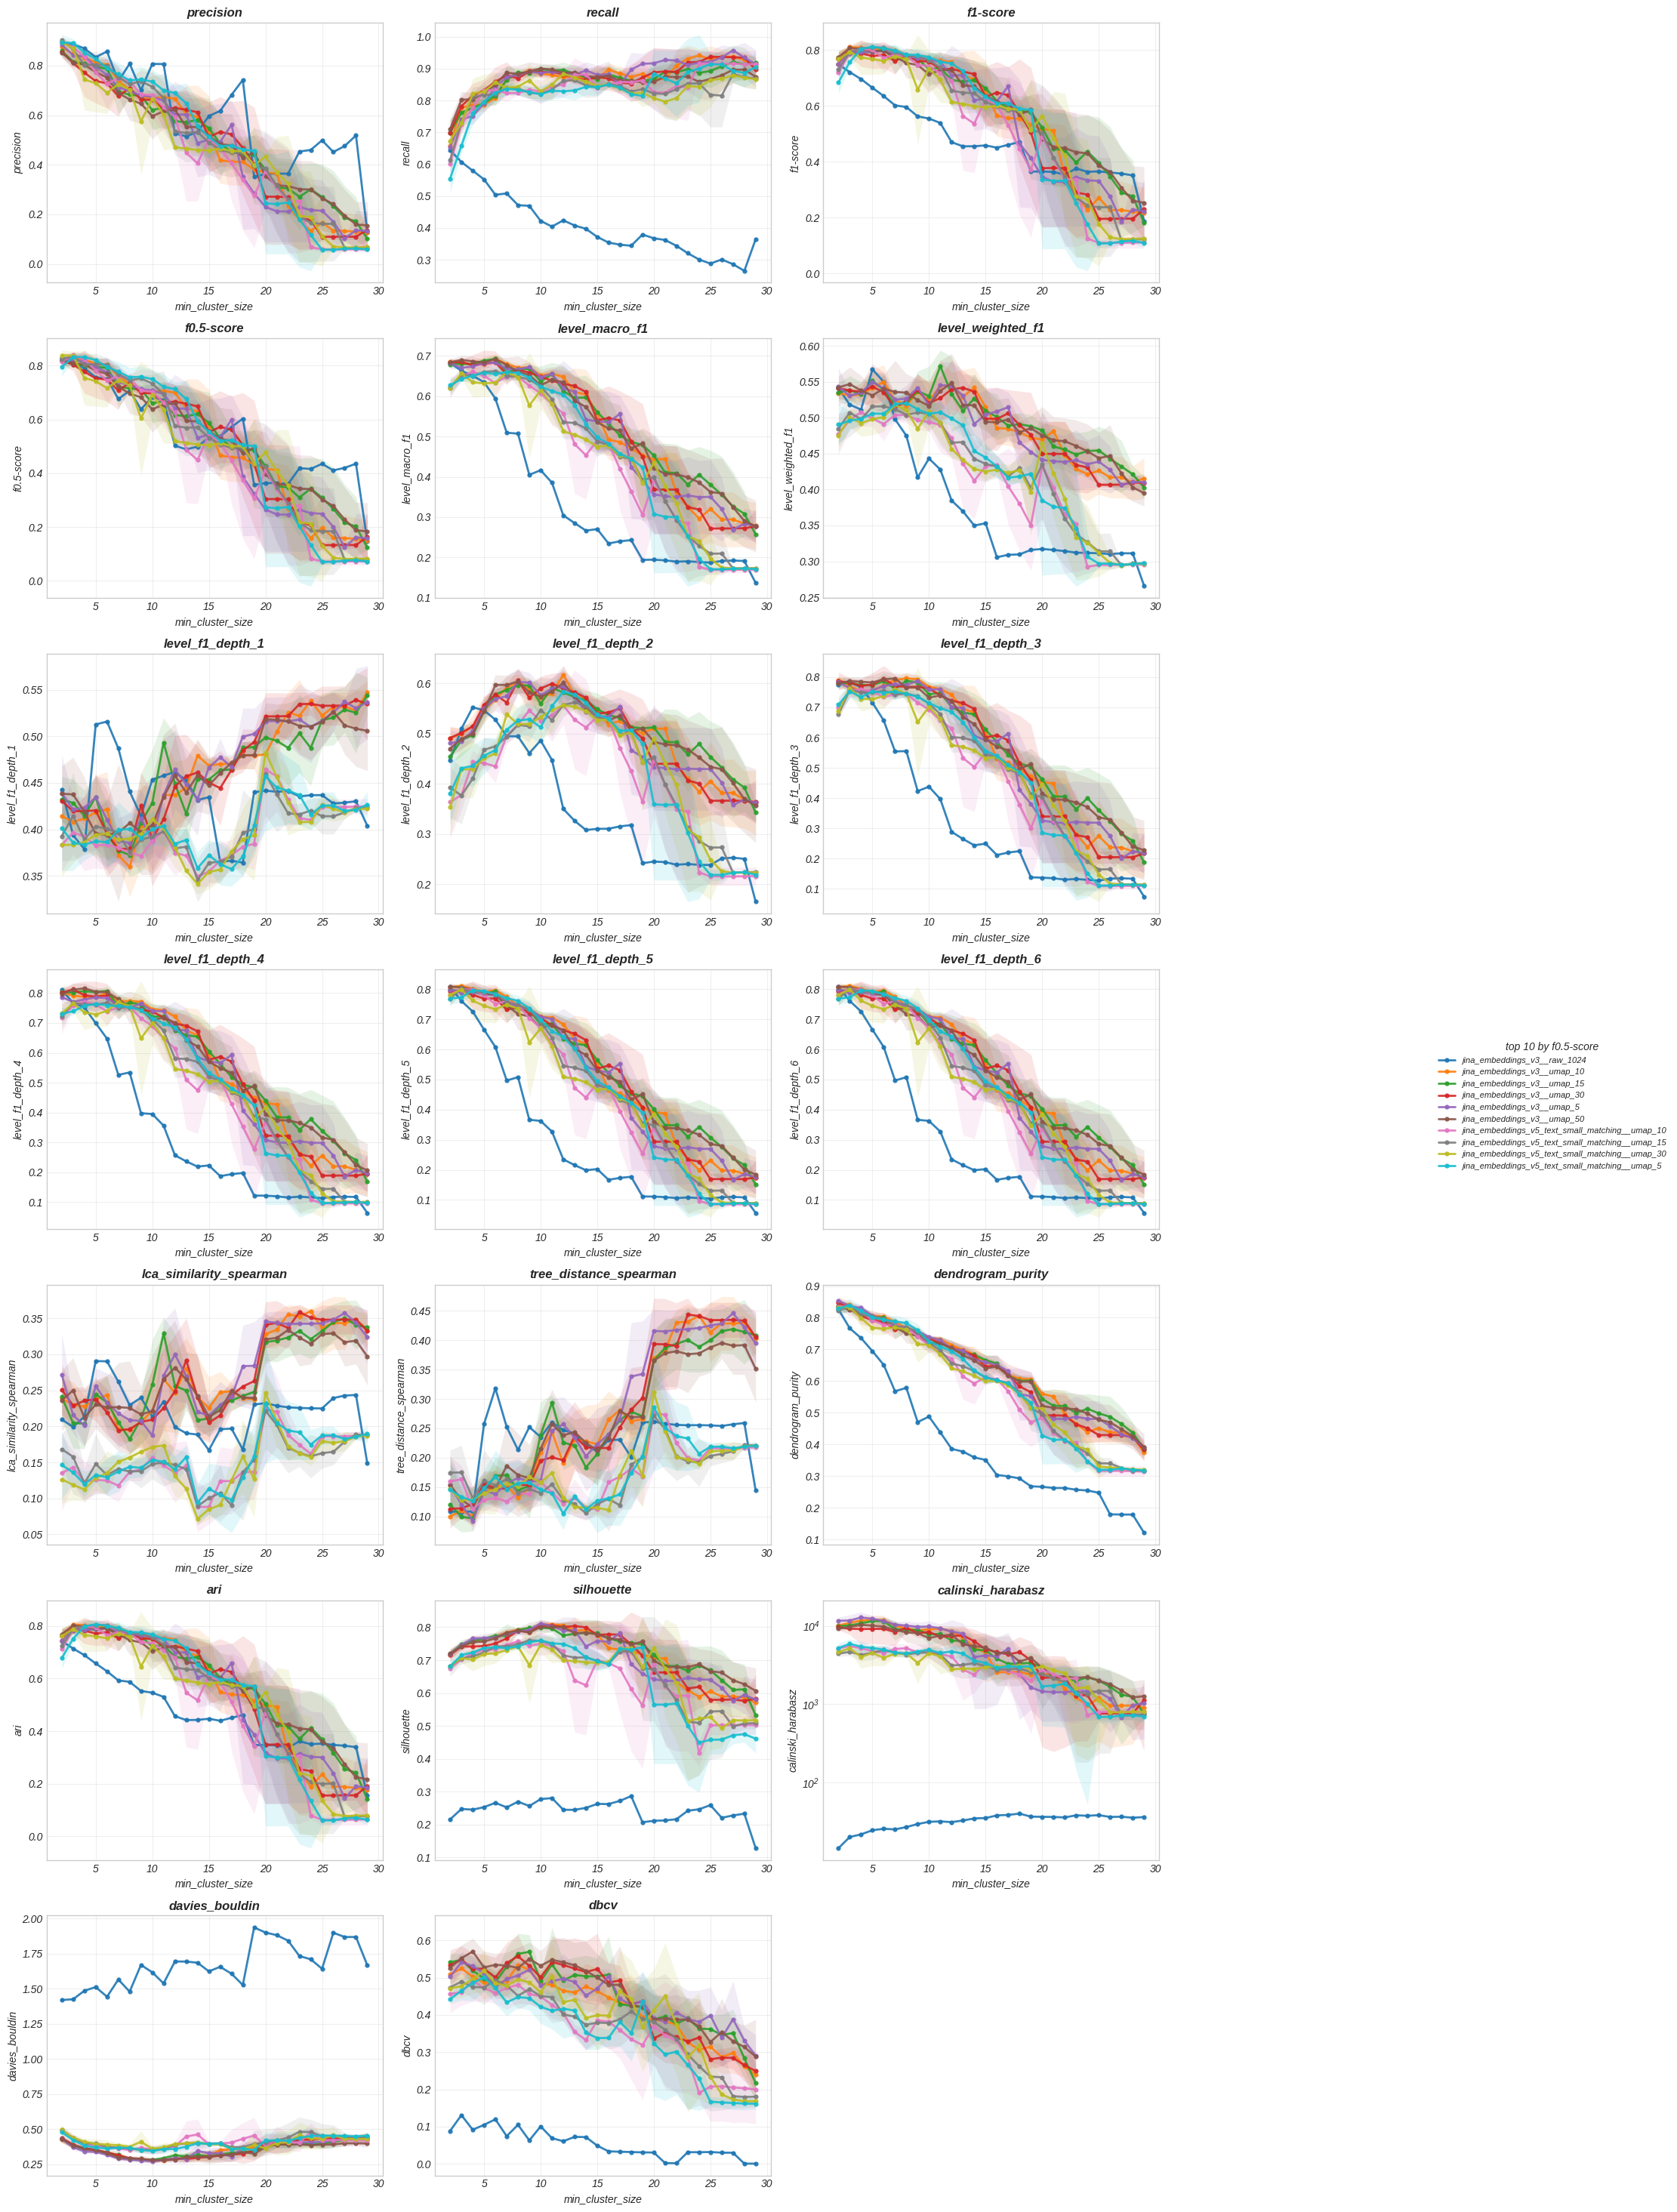

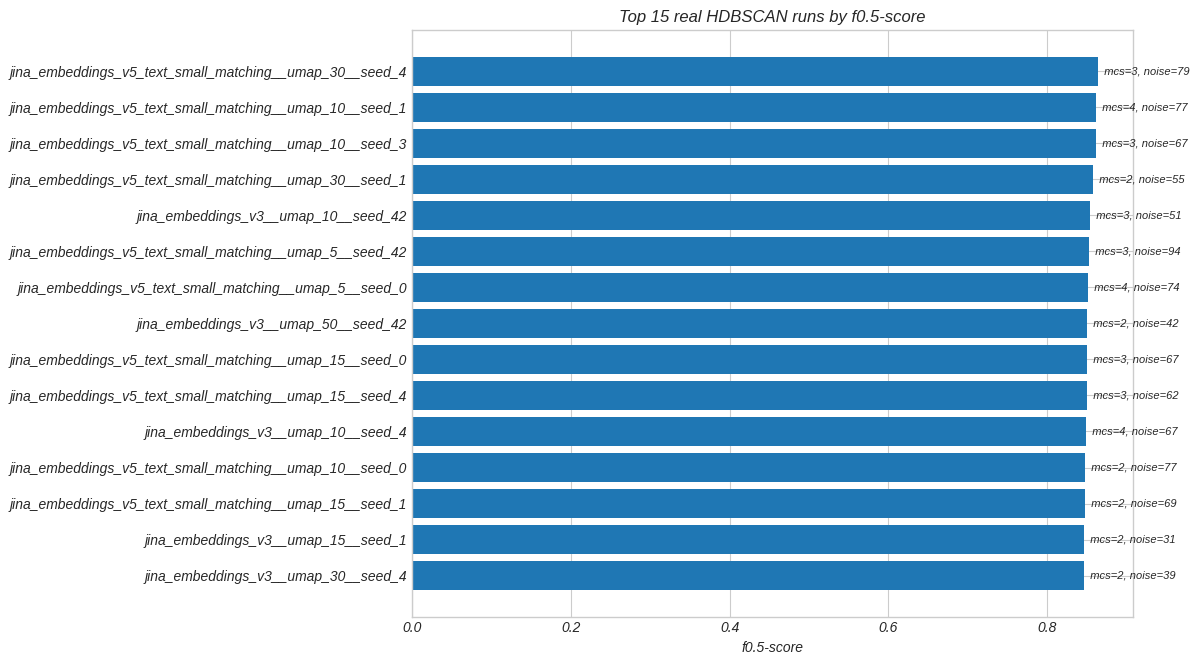

,space_id,min_cluster_size,f0.5-score,precision,recall,f1-score,level_macro_f1,level_weighted_f1,n_noise,n_pred_clusters
147,jina_embeddings_v5_text_small_matching__umap_3...,3,0.864747,0.892719,0.768434,0.825927,0.674593,0.520558,79,55
225,jina_embeddings_v5_text_small_matching__umap_1...,4,0.862177,0.879469,0.799316,0.837479,0.683343,0.512044,77,47
134,jina_embeddings_v5_text_small_matching__umap_1...,3,0.861936,0.906638,0.719948,0.802579,0.654749,0.494675,67,59
51,jina_embeddings_v5_text_small_matching__umap_3...,2,0.858400,0.907049,0.706770,0.794482,0.646952,0.484243,55,71
167,jina_embeddings_v3__umap_10__seed_42,3,0.854336,0.873213,0.786339,0.827502,0.690252,0.531694,51,53
130,jina_embeddings_v5_text_small_matching__umap_5...,3,0.853026,0.908824,0.684841,0.781092,0.653599,0.496179,94,57
218,jina_embeddings_v5_text_small_matching__umap_5...,4,0.851203,0.873014,0.773866,0.820455,0.661761,0.505614,74,51
92,jina_embeddings_v3__umap_50__seed_42,2,0.850485,0.891834,0.717433,0.795183,0.689632,0.534985,42,75
137,jina_embeddings_v5_text_small_matching__umap_1...,3,0.850210,0.892902,0.713711,0.793314,0.669839,0.560407,67,59
141,jina_embeddings_v5_text_small_matching__umap_1...,3,0.849810,0.895220,0.706468,0.789722,0.649014,0.491195,62,59


In [28]:
plot_hdbscan_results(
    "results_hdbscan_top_by_f05",
    metric_for_top="f0.5-score",
    top_n=10,
    aggregate_umap_seeds=True,
    show_std=True,
)

best_hdbscan_by_f05 = plot_hdbscan_best_summary(metric="f0.5-score", top_n=15)

In [29]:
def build_single_space_from_result_row(row, embeddings_dict, pca_dim=100):
    emb_name = row["embeddings"]
    reduction = row["reduction"]
    reduction_dim = int(row["reduction_dim"])
    X_raw = embeddings_dict[emb_name]

    if reduction == "raw":
        return normalize(X_raw)

    if reduction != "umap":
        raise ValueError(f"Unsupported reduction: {reduction}")

    use_pca = False if "jina_embeddings" in emb_name else True
    umap_seed = int(row.get("umap_seed", 42))

    return reduce_embeddings(
        X_raw,
        pca_dim=pca_dim,
        umap_dim=reduction_dim,
        return_twonn=False,
        use_pca=use_pca,
        umap_seed=umap_seed,
    )


def cluster_label_summary(y_true, y_pred, top_k=5):
    rows = []
    for cluster_id in sorted(label for label in set(y_pred) if label != -1):
        mask = y_pred == cluster_id
        labels = pd.Series(y_true[mask]).value_counts()
        size = int(mask.sum())
        dominant_label = labels.index[0]
        dominant_count = int(labels.iloc[0])

        rows.append({
            "cluster_id": cluster_id,
            "size": size,
            "dominant_label": dominant_label,
            "purity": dominant_count / size if size else np.nan,
            "top_labels": "; ".join(f"{idx}: {value}" for idx, value in labels.head(top_k).items()),
        })

    return pd.DataFrame(rows).sort_values(["purity", "size"], ascending=[True, False])


def plot_partition_from_result_row(
    row,
    embeddings_dict,
    y_true,
    title=None,
    annotate_top_clusters=12,
    random_state=42,
):
    X_space = build_single_space_from_result_row(row, embeddings_dict)
    min_cluster_size = int(row["min_cluster_size"])
    clusterer = HDBSCAN(
        min_cluster_size=min_cluster_size,
        metric="euclidean",
    ).fit(X_space)
    y_pred = clusterer.labels_

    if X_space.shape[1] == 2:
        X_plot = X_space
    else:
        X_plot = UMAP(
            n_components=2,
            metric="cosine",
            random_state=random_state,
        ).fit_transform(X_space)

    summary = cluster_label_summary(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(10, 7))
    noise_mask = y_pred == -1
    ax.scatter(
        X_plot[noise_mask, 0],
        X_plot[noise_mask, 1],
        c="lightgray",
        s=18,
        alpha=0.55,
        label="noise",
    )

    cluster_ids = sorted(label for label in set(y_pred) if label != -1)
    cmap = plt.get_cmap("tab20")

    for idx, cluster_id in enumerate(cluster_ids):
        mask = y_pred == cluster_id
        ax.scatter(
            X_plot[mask, 0],
            X_plot[mask, 1],
            s=24,
            alpha=0.8,
            color=cmap(idx % cmap.N),
        )

    for _, cluster_info in summary.sort_values("size", ascending=False).head(annotate_top_clusters).iterrows():
        cluster_id = cluster_info["cluster_id"]
        mask = y_pred == cluster_id
        centroid = X_plot[mask].mean(axis=0)
        ax.text(
            centroid[0],
            centroid[1],
            f"{cluster_id}: {cluster_info['dominant_label']}\n"
            f"p={cluster_info['purity']:.2f}, n={cluster_info['size']}",
            fontsize=8,
            bbox={"boxstyle": "round,pad=0.25", "fc": "white", "alpha": 0.75},
        )

    if title is None:
        title = (
            f"{row.get('selection_criterion', 'selected')} | {row['space_id']} | "
            f"min_cluster_size={min_cluster_size}"
        )

    ax.set_title(title)
    ax.set_xlabel("projection dim 1")
    ax.set_ylabel("projection dim 2")
    ax.legend(loc="best")
    plt.show()

    display(summary.head(20).round(4))
    return clusterer, summary


def plot_best_partitions(
    space_level_df,
    embeddings_dict,
    y_true,
    criteria=("best_by_f1", "best_by_f0.5", "best_by_level_macro_f1", "best_by_calinski_harabasz"),
    metric_by_criterion=None,
):
    if metric_by_criterion is None:
        metric_by_criterion = {
            "best_by_f1": "f1-score",
            "best_by_f0.5": "f0.5-score",
            "best_by_level_macro_f1": "level_macro_f1",
            "best_by_level_weighted_f1": "level_weighted_f1",
            "best_by_calinski_harabasz": "calinski_harabasz",
            "best_by_silhouette": "silhouette",
            "best_by_davies_bouldin": "davies_bouldin",
        }

    for criterion in criteria:
        part = space_level_df[space_level_df["selection_criterion"] == criterion]
        if part.empty:
            continue

        metric = metric_by_criterion[criterion]
        if criterion == "best_by_davies_bouldin":
            row = part.loc[part[metric].idxmin()]
        else:
            row = part.loc[part[metric].idxmax()]

        print(f"\nVisual inspection for {criterion}")
        display(row.to_frame("value"))
        plot_partition_from_result_row(
            row,
            embeddings_dict=embeddings_dict,
            y_true=y_true,
            title=f"{criterion}: {row['space_id']}",
        )



Visual inspection for best_by_f1


,value
selection_criterion,best_by_f1
selection_metric,f1-score
selection_direction,max
algorithm,hdbscan
hierarchy_method,agglomerative_centroid_average_cosine
space_id,jina_embeddings_v5_text_small_matching__umap_1...
embeddings,jina_embeddings_v5_text_small_matching
reduction,umap
reduction_dim,10
umap_seed,1


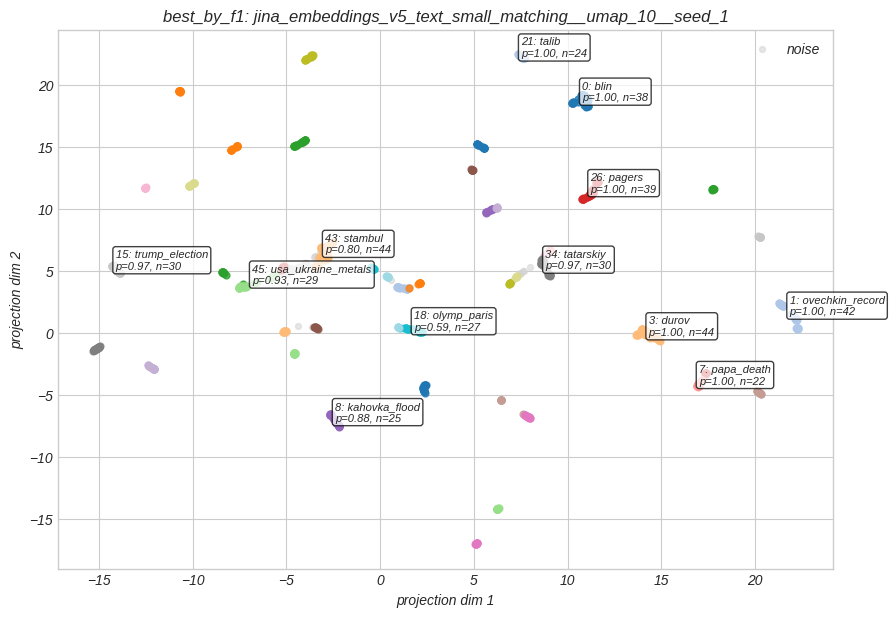

,cluster_id,size,dominant_label,purity,top_labels
11,11,10,neuralink,0.5000,neuralink: 5; starship: 5
33,33,6,shoot_makhachkala,0.5000,shoot_makhachkala: 3; explode_tulen: 2; novoru...
30,30,9,9may_politics,0.5556,9may_politics: 5; vuchich_ill: 4
13,13,7,merz_election,0.5714,merz_election: 4; adg_extreme: 3
18,18,27,olymp_paris,0.5926,olymp_paris: 16; olymp_paris_collapse: 10; 9ma...
46,46,5,russia_ukraine_negotiations,0.6000,russia_ukraine_negotiations: 3; oil_fall: 1; s...
23,23,11,misha_ill,0.6364,misha_ill: 7; medinskiy_writer_union: 3; strai...
22,22,17,pridnestr_gaz,0.6471,pridnestr_gaz: 11; pridnestr: 6
44,44,11,usa_russia_metals,0.7273,usa_russia_metals: 8; usa_ukraine_metals: 3
43,43,44,stambul,0.7955,stambul: 35; russia_ukraine_negotiations: 3; d...



Visual inspection for best_by_f0.5


,value
selection_criterion,best_by_f0.5
selection_metric,f0.5-score
selection_direction,max
algorithm,hdbscan
hierarchy_method,agglomerative_centroid_average_cosine
space_id,jina_embeddings_v5_text_small_matching__umap_3...
embeddings,jina_embeddings_v5_text_small_matching
reduction,umap
reduction_dim,30
umap_seed,4


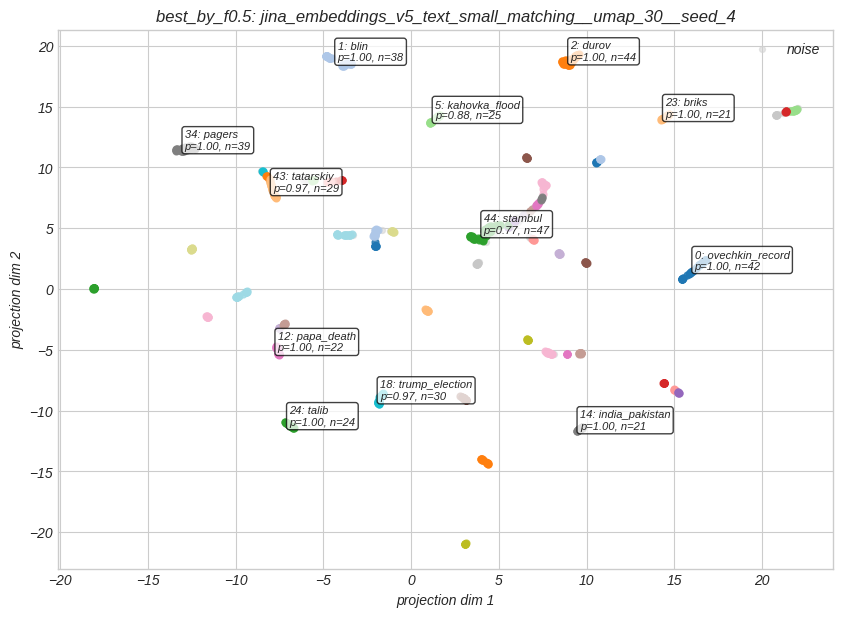

,cluster_id,size,dominant_label,purity,top_labels
49,49,5,russia_ukraine_negotiations,0.4000,russia_ukraine_negotiations: 2; trump_election...
48,48,4,nancy_visit,0.5000,nancy_visit: 2; trump_election: 1; stambul: 1
35,35,9,9may_politics,0.5556,9may_politics: 5; vuchich_ill: 4
16,16,7,merz_election,0.5714,merz_election: 4; adg_extreme: 3
42,42,5,shoot_makhachkala,0.6000,shoot_makhachkala: 3; explode_tulen: 1; tatars...
22,22,17,pridnestr_gaz,0.6471,pridnestr_gaz: 11; pridnestr: 6
25,25,13,olymp_paris_collapse,0.6923,olymp_paris_collapse: 9; olymp_paris: 3; 9may_...
44,44,47,stambul,0.7660,stambul: 36; russia_ukraine_negotiations: 3; d...
40,40,9,rebellion,0.7778,rebellion: 7; vagner_spb: 2
9,9,5,conclave,0.8000,conclave: 4; papa_death: 1



Visual inspection for best_by_level_macro_f1


,value
selection_criterion,best_by_level_macro_f1
selection_metric,level_macro_f1
selection_direction,max
algorithm,hdbscan
hierarchy_method,agglomerative_centroid_average_cosine
space_id,jina_embeddings_v3__umap_30__seed_2
embeddings,jina_embeddings_v3
reduction,umap
reduction_dim,30
umap_seed,2


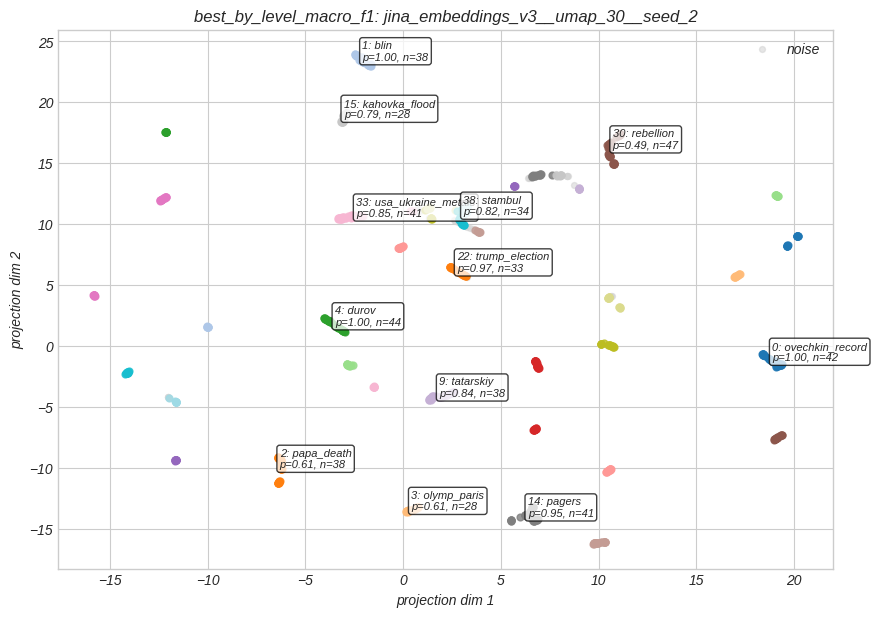

,cluster_id,size,dominant_label,purity,top_labels
36,36,7,russia_ukraine_negotiations,0.4286,russia_ukraine_negotiations: 3; stambul: 2; us...
30,30,47,rebellion,0.4894,rebellion: 23; prigozhin: 19; medinskiy_writer...
21,21,8,merz_election,0.5000,merz_election: 4; adg_extreme: 3; 9may_politic...
17,17,15,deepseek,0.6000,deepseek: 9; neuralink: 5; nancy_visit: 1
2,2,38,papa_death,0.6053,papa_death: 23; new_papa: 11; conclave: 4
3,3,28,olymp_paris,0.6071,olymp_paris: 17; olymp_paris_collapse: 10; kie...
7,7,18,pridnestr_gaz,0.6111,pridnestr_gaz: 11; pridnestr: 7
25,25,14,9may_politics,0.6429,9may_politics: 9; vuchich_ill: 4; briks: 1
16,16,18,submarine,0.7222,submarine: 13; starship: 5
34,34,16,straight_line,0.7500,straight_line: 12; straight_line_after: 4



Visual inspection for best_by_calinski_harabasz


,value
selection_criterion,best_by_calinski_harabasz
selection_metric,calinski_harabasz
selection_direction,max
algorithm,hdbscan
hierarchy_method,agglomerative_centroid_average_cosine
space_id,jina_embeddings_v3__umap_5__seed_4
embeddings,jina_embeddings_v3
reduction,umap
reduction_dim,5
umap_seed,4


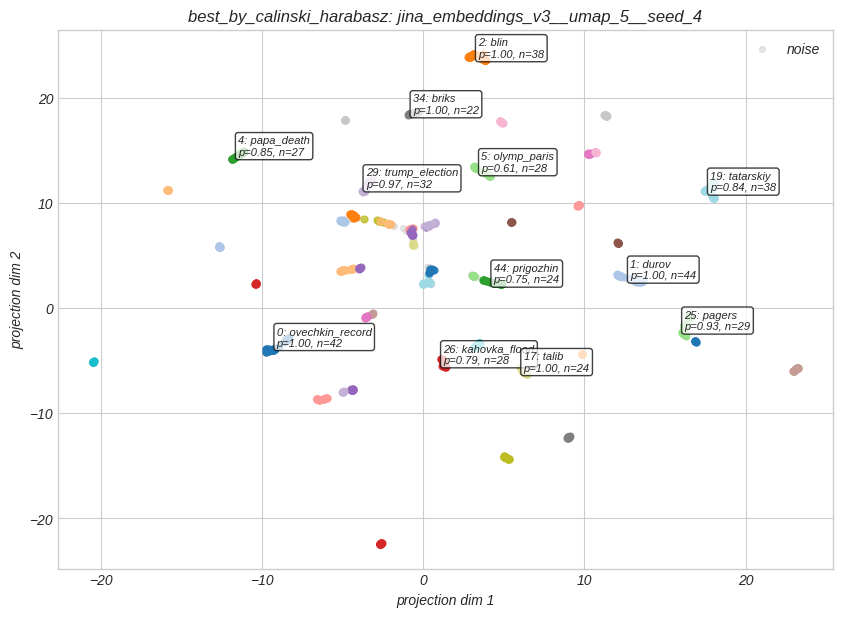

,cluster_id,size,dominant_label,purity,top_labels
7,7,19,deepseek,0.4737,deepseek: 9; neuralink: 5; team_spirit: 4; nan...
28,28,8,merz_election,0.5000,merz_election: 4; adg_extreme: 3; 9may_politic...
43,43,8,russia_ukraine_negotiations,0.5000,russia_ukraine_negotiations: 4; stambul: 2; us...
36,36,7,russia_ukraine_negotiations,0.5714,russia_ukraine_negotiations: 4; usa_ukraine_me...
5,5,28,olymp_paris,0.6071,olymp_paris: 17; olymp_paris_collapse: 10; kie...
11,11,18,pridnestr_gaz,0.6111,pridnestr_gaz: 11; pridnestr: 7
33,33,12,9may_politics,0.6667,9may_politics: 8; vuchich_ill: 4
48,48,12,stambul,0.6667,stambul: 8; russia_ukraine_negotiations: 3; do...
44,44,24,prigozhin,0.7500,prigozhin: 18; rebellion: 6
39,39,16,straight_line,0.7500,straight_line: 12; straight_line_after: 4


In [30]:
plot_best_partitions(space_level_df, embeddings_dict, y_true)

In [31]:
group_col = "space_id" if "space_id" in hdbscan_df.columns else "embeddings"
external_metrics_for_space_corr = globals().get("external_metrics_reduced", external_metrics)

for group_name, part in hdbscan_df.groupby(group_col):
    corr = spearman_corr_table(
        part,
        internal_metrics_for_corr,
        external_metrics_for_space_corr,
    )
    print(group_name)
    display(corr.round(6))

jina_embeddings_v3__raw_1024


,precision,recall,f1-score,f0.5-score,level_macro_f1,level_weighted_f1,level_f1_depth_1,level_f1_depth_2,level_f1_depth_3,level_f1_depth_4,level_f1_depth_5,level_f1_depth_6,lca_similarity_spearman,dendrogram_purity
silhouette,0.642036,0.178982,0.539135,0.617953,0.401204,0.189929,-0.011494,0.525452,0.409962,0.409414,0.407772,0.407772,-0.094691,0.420361
calinski_harabasz,-0.661741,-0.868637,-0.699507,-0.690203,-0.820471,-0.887247,-0.444992,-0.759168,-0.817734,-0.806787,-0.808429,-0.808429,-0.224412,-0.801861
davies_bouldin_inv,0.900383,0.665572,0.849480,0.891078,0.743295,0.565408,0.074439,0.735632,0.744937,0.750411,0.746579,0.746579,-0.149973,0.767926
dbcv,0.863164,0.840722,0.927203,0.883963,0.896004,0.819923,0.331691,0.869184,0.902573,0.905857,0.904215,0.904215,-0.001095,0.931034


jina_embeddings_v3__umap_10__seed_0


,precision,recall,f1-score,f0.5-score,level_macro_f1,level_weighted_f1,level_f1_depth_1,level_f1_depth_2,level_f1_depth_3,level_f1_depth_4,level_f1_depth_5,level_f1_depth_6,lca_similarity_spearman,dendrogram_purity
silhouette,0.761357,-0.301587,0.783251,0.763547,0.768304,0.901328,-0.558203,0.865198,0.836732,0.760093,0.750787,0.750787,-0.539483,0.745860
calinski_harabasz,0.961138,-0.695129,0.963875,0.960591,0.916655,0.796770,-0.799233,0.669769,0.844943,0.929246,0.929246,0.929246,-0.617216,0.919940
davies_bouldin_inv,0.635468,-0.185003,0.685276,0.637110,0.660463,0.787464,-0.440427,0.806076,0.749145,0.652251,0.638018,0.638018,-0.433283,0.633092
dbcv,0.812808,-0.349754,0.787630,0.817187,0.828521,0.768852,-0.672419,0.659915,0.892021,0.835090,0.848775,0.848775,-0.698235,0.856986


jina_embeddings_v3__umap_10__seed_1


...

,precision,recall,f1-score,f0.5-score,level_macro_f1,level_weighted_f1,level_f1_depth_1,level_f1_depth_2,level_f1_depth_3,level_f1_depth_4,level_f1_depth_5,level_f1_depth_6,lca_similarity_spearman,dendrogram_purity
silhouette,0.675424,0.020799,0.813355,0.759715,0.756431,0.731253,-0.286575,0.844007,0.784346,0.719212,0.750958,0.750958,-0.187192,0.675972
calinski_harabasz,0.972633,-0.434045,0.798030,0.890531,0.875205,0.851669,-0.061585,0.705528,0.834702,0.873563,0.872469,0.872469,0.160372,0.841270
davies_bouldin_inv,0.729611,-0.354132,0.723591,0.788725,0.690203,0.631637,-0.169974,0.708812,0.723043,0.665572,0.690750,0.690750,0.157635,0.623974
dbcv,0.241379,-0.450465,0.151067,0.168582,0.258894,0.245211,0.254550,-0.029557,0.227148,0.275315,0.268747,0.268747,0.411056,0.314176


tfidf_svd__umap_5__seed_4


,precision,recall,f1-score,f0.5-score,level_macro_f1,level_weighted_f1,level_f1_depth_1,level_f1_depth_2,level_f1_depth_3,level_f1_depth_4,level_f1_depth_5,level_f1_depth_6,lca_similarity_spearman,dendrogram_purity
silhouette,0.255063,-0.338259,0.515599,0.365627,0.222253,0.354728,0.374435,0.394690,0.297249,0.194334,0.187765,0.187765,0.425346,0.096893
calinski_harabasz,0.979201,-0.643678,0.625068,0.913519,0.870125,0.831258,0.116874,0.404817,0.804434,0.877241,0.887095,0.887095,0.840016,0.899138
davies_bouldin_inv,0.588396,-0.371648,0.759168,0.738369,0.602436,0.659915,0.341317,0.485836,0.641850,0.564664,0.590940,0.590940,0.651156,0.488025
dbcv,0.530925,-0.610290,0.440613,0.530925,0.508280,0.399891,-0.269057,0.601341,0.477077,0.491310,0.572328,0.572328,0.394416,0.564117


tfidf_svd__umap_5__seed_42


,precision,recall,f1-score,f0.5-score,level_macro_f1,level_weighted_f1,level_f1_depth_1,level_f1_depth_2,level_f1_depth_3,level_f1_depth_4,level_f1_depth_5,level_f1_depth_6,lca_similarity_spearman,dendrogram_purity
silhouette,0.274767,0.418777,0.636563,0.386426,0.340449,0.321839,-0.141215,0.310892,0.492611,0.395183,0.239737,0.239737,-0.126437,0.127531
calinski_harabasz,0.981938,-0.069249,0.586207,0.900930,0.850575,0.888342,0.209086,0.462507,0.791461,0.833607,0.873016,0.873016,0.330049,0.908593
davies_bouldin_inv,0.740558,0.330368,0.834154,0.887794,0.704433,0.692939,-0.188834,0.551724,0.785441,0.781609,0.731253,0.731253,-0.093049,0.688013
dbcv,0.494253,0.328726,0.541872,0.542967,0.659004,0.620142,-0.090859,0.678708,0.628352,0.617953,0.621237,0.621237,-0.017515,0.577449


In [32]:
group_col = "space_id" if "space_id" in hdbscan_df.columns else "embeddings"

for group_name, part in hdbscan_df.groupby(group_col):
    best_by_f1 = part.loc[part["f1-score"].idxmax()]
    best_by_f05 = part.loc[part["f0.5-score"].idxmax()] if "f0.5-score" in part.columns else None
    best_by_level_macro_f1 = part.loc[part["level_macro_f1"].idxmax()]
    best_by_ch = part.loc[part["calinski_harabasz"].idxmax()]
    best_by_sil = part.loc[part["silhouette"].idxmax()]
    best_by_db = part.loc[part["davies_bouldin"].idxmin()]
    best_by_dbcv = part.loc[part["dbcv"].idxmax()]

    print("\n", group_name)
    print("Best by F1:", best_by_f1["min_cluster_size"], " | ", best_by_f1["f1-score"])
    if best_by_f05 is not None:
        print(
            "Best by F0.5:", best_by_f05["min_cluster_size"],
            " | ", best_by_f05["f0.5-score"],
            "precision:", best_by_f05["precision"],
            "recall:", best_by_f05["recall"],
        )
    print("Best by level macro F1:", best_by_level_macro_f1["min_cluster_size"], " | ", best_by_level_macro_f1["level_macro_f1"])
    print("=" * 50)
    print("Selected by CH:", best_by_ch["min_cluster_size"], " | ", best_by_ch["f1-score"], best_by_ch["level_macro_f1"])
    print("Selected by silhouette:", best_by_sil["min_cluster_size"], " | ", best_by_sil["f1-score"], best_by_sil["level_macro_f1"])
    print("Selected by DB:", best_by_db["min_cluster_size"], " | ", best_by_db["f1-score"], best_by_db["level_macro_f1"])
    print("Selected by dbcv:", best_by_dbcv["min_cluster_size"], " | ", best_by_dbcv["f1-score"], best_by_dbcv["level_macro_f1"])



 jina_embeddings_v3__raw_1024
Best by F1: 2  |  0.7485236508214933
Best by F0.5: 2  |  0.8293814299411749 precision: 0.8937447640323932 recall: 0.6438990041243335
Best by level macro F1: 2  |  0.6819284312895246
Selected by CH: 18  |  0.47051546391752574 0.24304482557498472
Selected by silhouette: 18  |  0.47051546391752574 0.24304482557498472
Selected by DB: 2  |  0.7485236508214933 0.6819284312895246
Selected by dbcv: 3  |  0.7205636493909721 0.6626187854330454

 jina_embeddings_v3__umap_10__seed_0
Best by F1: 6  |  0.8146637434354764
Best by F0.5: 2  |  0.8379078073686985 precision: 0.8800352467270897 recall: 0.7032491701036113
Best by level macro F1: 6  |  0.7002365803947604
Selected by CH: 6  |  0.8146637434354764 0.7002365803947604
Selected by silhouette: 12  |  0.7678445229681979 0.6573179008699173
Selected by DB: 11  |  0.7670437307675639 0.6646570121064904
Selected by dbcv: 3  |  0.8012415712297978 0.6688946850547426

 jina_embeddings_v3__umap_10__seed_1
Best by F1: 4  |  0.8